# 크립토 계층적 강화학습 포트폴리오 운용 (EarnHFT 이식)

`crypto_rl_trading_colab.ipynb`(단일 PPO)가 2026 테스트 구간에서 총수익률 -75.68%(Sharpe -4.2, MDD -79%)로
등가중 벤치마크(+2.66%)에 크게 뒤진 것을 확인한 뒤, EarnHFT(Qin et al. 2024, AAAI)의 계층적 RL 구조를
이식해 개선을 시도한다.

**사전 조건**: `crypto_hybrid_model_colab.ipynb` 실행 후 Drive에 `crypto_rl_embeddings.h5` 존재.
`crypto_rl_trading_colab.ipynb`로 학습한 `crypto_ppo_portfolio.zip`이 있으면 3-way 비교에 포함(없어도 동작).

## 구조 — 기존 44종목 포트폴리오 PPO는 유지하고 계층적 기법만 이식

| 단계 | EarnHFT 원문 | 이 노트북에서의 적응 |
|------|------|------|
| Stage A: 레짐 분할 | Algorithm 3 (DTW+기울기 기반 시장 세분화) | `crypto/market_segmentation.py` 이식, 44종목 등가중 지수에 적용 |
| Stage B: 에이전트 풀 | 200개 에이전트, β 선호도 샘플링 | 4개 에이전트(β 스윕), `CryptoPortfolioEnv`를 청크 단위 에피소드로 재구성 |
| Stage C: 라우터 | 분 단위 DDQN 라우터 | 일 단위(48버킷) DQN 라우터, 매크로 지표 기반 |
| Stage I: Q-teacher | 단일자산 DP 최적 액션가치 | **제외** — 연속 포트폴리오 액션 공간에 자연스럽게 대응되지 않음 |

논문 자체가 "PPO는 수수료 때문에 dummy policy로 수렴하기 쉽고 bear market에서 특히 취약하다"고
지적하며 그것을 이기는 결과를 보이는데, 이는 우리가 겪은 실패 패턴과 정확히 일치한다.

**차이점 요약**(보고서용):
- 저수준 단위: 초 단위 LOB → 30분 버킷(기존 파이프라인 grain에 맞춤)
- 고수준 라우팅 단위: 분 단위 → 1일(48버킷). 논문의 "초→분(60배)" 대신 "30분→1일(48배)" 비율 사용
- 에이전트 풀 크기: 200개 → 4개 (Colab 컴퓨팅 예산)
- DDQN → SB3 `DQN`으로 근사

> 런타임 → 런타임 유형 변경 → **T4 GPU** 선택 후 실행 (PPO/DQN 모두 CPU 사용, GPU는 불필요하지만 기본 설정 유지).
> 기존 노트북보다 학습량이 많다(풀 4개 + 라우터) — Colab 세션 제한에 걸리면 아래 `POOL_TIMESTEPS_EACH`,
> `ROUTER_TOTAL_TIMESTEPS`를 줄여서 재실행.


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q stable-baselines3[extra] gymnasium h5py pyarrow


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 10.3 MB/s eta 0:00:00


In [2]:
import warnings
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['axes.unicode_minus'] = False

DRIVE_ROOT = Path('/content/drive/MyDrive/졸업프로젝트')
DATA_DIR   = DRIVE_ROOT / 'data'
CRYPTO_DIR = DATA_DIR / 'crypto'
FEAT_DIR   = CRYPTO_DIR / 'features_5m'
MODEL_DIR  = DRIVE_ROOT / 'models'
POOL_DIR   = MODEL_DIR / 'crypto_hrl_pool'

RL_EMB_H5      = CRYPTO_DIR / 'crypto_rl_embeddings.h5'
ORIG_PPO_PATH  = MODEL_DIR / 'crypto_ppo_portfolio.zip'   # crypto_rl_trading_colab.ipynb 산출물(있으면 비교에 포함)

EMB_DIM    = 64
TC         = 0.001    # 거래비용 (Binance taker fee 기준)
BUCKET_SEC = 1800     # 30분 버킷

RL_TRAIN_START = '2025-01-01'
RL_TRAIN_END   = '2025-12-31'
RL_TEST_START  = '2026-01-01'
RL_TEST_END    = '2099-12-31'   # 열린 구간

# --- Stage A/B/C 하이퍼파라미터 ---
N_LABELS              = 5          # 레짐 라벨 수 (bear/pullback/sideways/rally/bull)
RISK_THRESHOLD        = 0.2        # EarnHFT θ — 상하위 라벨 경계 분위수 폭
LOWPASS_WINDOW        = 48         # 레짐 분할 저역통과 윈도우 = 1일(30분×48)
POOL_BETAS            = [-90, -30, 30, 90]   # Stage B 선호도 스윕 (논문 [-90,-10,30,100] 근사)
POOL_TIMESTEPS_EACH   = 100_000    # 풀 에이전트 1개당 학습 스텝 (원본 300k와 총량 비슷하게)
ROUTE_BUCKETS         = 48         # Stage C 라우팅 단위 = 1일
MACRO_WINDOW           = 96        # 라우터 상태에 포함할 최근 버킷 수 (=2일)
ROUTER_TOTAL_TIMESTEPS = 20_000    # 라우터(=일 단위) 학습 스텝

assert RL_EMB_H5.exists(), 'crypto_rl_embeddings.h5 없음 — crypto_hybrid_model_colab.ipynb 먼저 실행'
print('경로 확인 완료')


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


경로 확인 완료


## 1. RL 임베딩 로드 & 인덱스 구축

심볼마다 5분봉 backfill 시작 시각이 달라 30분 간격 샘플의 초 단위 timestamp가 서로 어긋난다(위상 차이). `ts // BUCKET_SEC`로 30분 버킷에 매핑하면 심볼별로 정확히 버킷당 1개씩 떨어져(STRIDE=6이 정확히 1버킷과 같으므로 충돌 없음) 서로 다른 위상이라도 같은 30분 창으로 정렬된다.

In [3]:
print('crypto_rl_embeddings.h5 로드 중...')
with h5py.File(RL_EMB_H5, 'r') as f:
    symbols_raw = f['symbols'][:]
    ts_raw      = f['timestamps'][:]     # epoch seconds (UTC)
    embs_all    = f['embeddings'][:]     # (N, 64)

symbols_list = [s.decode() for s in symbols_raw]
ts_list      = ts_raw.astype(np.int64).tolist()

# (symbol, 30분 버킷) → 임베딩 인덱스
emb_index  = {}
sym_ts_set = {}   # 심볼별로 임베딩 추출에 실제 쓰인 초 단위 timestamp 집합 (수익률 정확 매칭용)
for i, (s, t) in enumerate(zip(symbols_list, ts_list)):
    emb_index[(s, t // BUCKET_SEC)] = i
    sym_ts_set.setdefault(s, set()).add(t)

symbols  = sorted(set(symbols_list))
N_ASSETS = len(symbols)
print(f'임베딩: {embs_all.shape} | 심볼: {N_ASSETS}개 | 인덱스: {len(emb_index):,}개')


crypto_rl_embeddings.h5 로드 중...
임베딩: (1079473, 64) | 심볼: 44개 | 인덱스: 1,079,473개


## 2. 30분 수익률(RetTarget_6b) 로드

In [4]:
print('features_5m parquet에서 RetTarget_6b 로드 중...')
files = sorted(glob.glob(str(FEAT_DIR / '*.parquet')))
assert files, f'피처 parquet 없음: {FEAT_DIR}'

rl_start_ts = pd.Timestamp(RL_TRAIN_START, tz='UTC')
ret_index   = {}

for fp in files:
    sym = Path(fp).stem
    valid_ts = sym_ts_set.get(sym)
    if not valid_ts:
        continue
    df = pd.read_parquet(fp, columns=['datetime', 'RetTarget_6b'])
    df = df[df['datetime'] >= rl_start_ts]
    epoch = df['datetime'].values.astype('int64') // 10**9   # ts_list와 동일 단위(초)
    y     = df['RetTarget_6b'].values
    # 임베딩 추출에 실제 쓰인 timestamp만 매칭 — 같은 버킷 내 다른 5분봉과 섞이지 않도록
    for t, r in zip(epoch, y):
        t = int(t)
        if t in valid_ts and not np.isnan(r):
            ret_index[(sym, t // BUCKET_SEC)] = float(r)

all_buckets = sorted(set(t // BUCKET_SEC for t in ts_list))
print(f'수익률 인덱스: {len(ret_index):,}개 | 전체 30분 버킷: {len(all_buckets):,}개')


features_5m parquet에서 RetTarget_6b 로드 중...
수익률 인덱스: 1,079,473개 | 전체 30분 버킷: 26,840개


## 3. CryptoPortfolioEnv (Gymnasium) — 기존과 동일, 변경 없음

In [5]:
class CryptoPortfolioEnv(gym.Env):
    """
    크립토 44종목 개별 자산 기반 포트폴리오 운용 환경 (클러스터링 없음)

    State:  종목별 임베딩(N×64) + 현재 비중(N) → N*64+N dim
    Action: 종목별 목표 포트폴리오 비중 (N-dim, Softmax 정규화)
    Reward: 30분 포트폴리오 수익률(RetTarget_6b, 이미 forward-looking) − 거래비용
    스텝 = 30분 버킷(BUCKET_SEC) 단위 — emb_index/ret_index 모두 (symbol, bucket) 키.
    """
    metadata = {'render_modes': []}

    def __init__(self, buckets, symbols, emb_index, embs_all, ret_index,
                 emb_dim=64, tc=0.001):
        super().__init__()
        self.buckets    = buckets
        self.symbols    = symbols
        self.n_assets   = len(symbols)
        self.emb_index  = emb_index
        self.embs_all   = embs_all
        self.ret_index  = ret_index
        self.emb_dim    = emb_dim
        self.tc         = tc

        obs_dim = self.n_assets * emb_dim + self.n_assets
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space      = spaces.Box(-3.0, 3.0, shape=(self.n_assets,), dtype=np.float32)

    def _asset_emb(self, bucket):
        """종목별 임베딩 — 해당 버킷에 데이터 없으면 0-vector(상장 전/상폐 등)"""
        embs = []
        for sym in self.symbols:
            idx = self.emb_index.get((sym, bucket))
            embs.append(self.embs_all[idx] if idx is not None else np.zeros(self.emb_dim, dtype=np.float32))
        return np.concatenate(embs)  # (N*64,)

    def _asset_ret(self, bucket):
        """종목별 30분 수익률 — 없으면 0(그 자산은 보유해도 손익 없음으로 취급)"""
        return np.array([self.ret_index.get((sym, bucket), 0.0) for sym in self.symbols], dtype=np.float32)

    def _get_obs(self):
        b = self.buckets[self.t]
        return np.concatenate([self._asset_emb(b), self.weights]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t               = 0
        self.weights         = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.value_history   = [1.0]
        self.turnover_history = []
        return self._get_obs(), {}

    def step(self, action):
        # Softmax로 비중 정규화
        action  = np.exp(action - action.max())
        action  = action / action.sum()

        # 거래비용
        turnover = float(np.abs(action - self.weights).sum())  # 비중 변화량(진단용)
        tc_cost  = self.tc * turnover

        # RetTarget_6b는 현재 버킷 자체에 forward 수익률이 이미 인코딩되어 있음
        b          = self.buckets[self.t]
        asset_rets = self._asset_ret(b)
        port_ret   = float((action * asset_rets).sum())

        self.portfolio_value *= (1 + port_ret - tc_cost)
        self.weights           = action.copy()
        self.value_history.append(self.portfolio_value)
        self.turnover_history.append(turnover)
        self.t                += 1

        done = (self.t >= len(self.buckets) - 1)
        reward = float(port_ret - tc_cost)

        info = {'portfolio_value': self.portfolio_value, 'port_ret': port_ret, 'turnover': turnover, 'tc_cost': tc_cost}
        return self._get_obs(), reward, done, False, info


In [6]:
def bucket_to_ts(b):
    return pd.Timestamp(b * BUCKET_SEC, unit='s', tz='UTC')

def bucket_to_date(b):
    return bucket_to_ts(b).strftime('%Y-%m-%d')

train_buckets = [b for b in all_buckets if RL_TRAIN_START <= bucket_to_date(b) <= RL_TRAIN_END]
test_buckets  = [b for b in all_buckets if RL_TEST_START  <= bucket_to_date(b) <= RL_TEST_END]
print(f'학습 기간: {bucket_to_ts(train_buckets[0])} ~ {bucket_to_ts(train_buckets[-1])} ({len(train_buckets):,}스텝)')
print(f'테스트 기간: {bucket_to_ts(test_buckets[0])} ~ {bucket_to_ts(test_buckets[-1])} ({len(test_buckets):,}스텝)')

env_kwargs = dict(
    symbols=symbols, emb_index=emb_index, embs_all=embs_all,
    ret_index=ret_index, emb_dim=EMB_DIM, tc=TC,
)

test_env = CryptoPortfolioEnv(test_buckets, **env_kwargs)

print('\n환경 유효성 검사...')
check_env(CryptoPortfolioEnv(train_buckets[:100], **env_kwargs), warn=True)
print('OK')


학습 기간: 2025-01-01 00:00:00+00:00 ~ 2025-12-31 23:30:00+00:00 (17,520스텝)
테스트 기간: 2026-01-01 00:00:00+00:00 ~ 2026-07-14 03:30:00+00:00 (9,320스텝)

환경 유효성 검사...
OK


## 4. Stage A — 시장 레짐 분할 (EarnHFT Algorithm 3)

44종목 등가중 지수(equal-weight NAV curve)를 만들어 저역통과 필터 → 극값 분할 → 인접구간 병합(기울기차+DTW) →
기울기 분위수 라벨링을 적용한다. 결과는 (a) 각 30분 버킷의 레짐 라벨, (b) 라벨이 바뀌지 않는 연속 구간(chunk) 목록.

로컬 `crypto/market_segmentation.py`와 동일한 코드(Colab은 로컬 저장소를 마운트하지 않으므로 셀에 직접 포함).
로컬에서 BTC 종가로 검증했을 때(1일 저역통과, 2025-01~2026-07 구간) 936개 극값 기반 구간이 187개 레짐 구간(평균 약
3일)으로 병합되고 sideways/rally/pullback/bear/bull 5개 라벨에 고르게 분포하는 것을 확인했다.

In [ ]:
# crypto/market_segmentation.py 이식 (Colab은 저장소를 마운트하지 않으므로 동일 코드를 셀에 포함)
REGIME_NAMES = {1: 'bear', 2: 'pullback', 3: 'sideways', 4: 'rally', 5: 'bull'}
_DTW_MAX_LEN = 200


@dataclass
class MarketSegments:
    labels: pd.Series
    chunks: pd.DataFrame


def _zscore(x):
    std = x.std()
    return (x - x.mean()) / std if std > 1e-12 else np.zeros_like(x)


def _downsample(x, max_len=_DTW_MAX_LEN):
    if len(x) <= max_len:
        return x
    idx = np.linspace(0, len(x) - 1, max_len).round().astype(int)
    return x[idx]


def _dtw_distance(a, b):
    a, b = _downsample(a), _downsample(b)
    n, m = len(a), len(b)
    cost = np.full((n + 1, m + 1), np.inf)
    cost[0, 0] = 0.0
    for i in range(1, n + 1):
        ai = a[i - 1]
        row, prev = cost[i], cost[i - 1]
        for j in range(1, m + 1):
            row[j] = abs(ai - b[j - 1]) + min(prev[j], row[j - 1], prev[j - 1])
    return float(cost[n, m])


def _slope(x):
    if len(x) < 2:
        return 0.0
    t = np.arange(len(x), dtype=np.float64)
    a, _ = np.polyfit(t, x, 1)
    return float(a)


def _find_extrema_indices(x):
    d = np.diff(x)
    sign = np.sign(d)
    sign[sign == 0] = 1
    change = np.where(np.diff(sign) != 0)[0] + 1
    idx = np.concatenate(([0], change, [len(x) - 1]))
    return np.unique(idx)


def _merge_pass(x, bounds, merge_quantile):
    if len(bounds) <= 2:
        return bounds, False
    seg_ranges = list(zip(bounds[:-1], bounds[1:]))
    slopes = [_slope(x[a:b + 1]) for a, b in seg_ranges]
    if len(seg_ranges) < 2:
        return bounds, False
    slope_diffs = [abs(slopes[i + 1] - slopes[i]) for i in range(len(slopes) - 1)]
    dtw_dists = [
        _dtw_distance(
            _zscore(x[seg_ranges[i][0]:seg_ranges[i][1] + 1]),
            _zscore(x[seg_ranges[i + 1][0]:seg_ranges[i + 1][1] + 1]),
        )
        for i in range(len(seg_ranges) - 1)
    ]
    slope_thresh = np.quantile(slope_diffs, merge_quantile)
    dtw_thresh = np.quantile(dtw_dists, merge_quantile)

    new_bounds = [bounds[0]]
    merged_any = False
    i = 0
    while i < len(seg_ranges):
        can_merge = (
            i < len(seg_ranges) - 1
            and slope_diffs[i] <= slope_thresh
            and dtw_dists[i] <= dtw_thresh
        )
        if can_merge:
            new_bounds.append(seg_ranges[i + 1][1])
            merged_any = True
            i += 2
        else:
            new_bounds.append(seg_ranges[i][1])
            i += 1
    return new_bounds, merged_any


def _absorb_short_segments(x, bounds, min_length):
    while len(bounds) > 2:
        seg_ranges = list(zip(bounds[:-1], bounds[1:]))
        lengths = [b - a + 1 for a, b in seg_ranges]
        shortest = int(np.argmin(lengths))
        if lengths[shortest] >= min_length:
            break
        slopes = [_slope(x[a:b + 1]) for a, b in seg_ranges]
        left_diff = abs(slopes[shortest] - slopes[shortest - 1]) if shortest > 0 else np.inf
        right_diff = (
            abs(slopes[shortest] - slopes[shortest + 1]) if shortest < len(seg_ranges) - 1 else np.inf
        )
        drop_idx = shortest if left_diff <= right_diff else shortest + 1
        bounds = bounds[:drop_idx] + bounds[drop_idx + 1:]
    return bounds


def segment_and_label(series, n_labels=5, risk_threshold=0.2, lowpass_window=48,
                       merge_quantile=0.35, max_merge_iters=50, min_segment_length=None):
    """가격 시계열을 레짐 구간으로 분할하고 라벨을 부여한다 (EarnHFT Algorithm 3 이식).
    로그가격(buy&hold net curve의 로그) 기준으로 계산해 가격 스케일 왜곡을 방지한다."""
    x_raw = series.to_numpy(dtype=np.float64)
    if len(x_raw) < 3:
        raise ValueError('series가 너무 짧습니다 (최소 3개 포인트 필요)')
    if np.any(x_raw <= 0):
        raise ValueError('series는 로그 변환을 위해 모두 양수여야 합니다')

    x_log = np.log(x_raw)
    x_smooth = pd.Series(x_log).rolling(lowpass_window, min_periods=1, center=True).mean().to_numpy()

    bounds = _find_extrema_indices(x_smooth).tolist()
    for _ in range(max_merge_iters):
        bounds, merged = _merge_pass(x_smooth, bounds, merge_quantile)
        if not merged or len(bounds) <= 2:
            break
    bounds = _absorb_short_segments(x_log, bounds, min_segment_length or lowpass_window)

    seg_ranges = list(zip(bounds[:-1], bounds[1:]))
    slopes = np.array([_slope(x_log[a:b + 1]) for a, b in seg_ranges])

    theta = risk_threshold
    H = np.quantile(slopes, 1 - theta / 2)
    L = np.quantile(slopes, theta / 2)

    labels = np.empty(len(slopes), dtype=np.int64)
    for i, s in enumerate(slopes):
        if s > H:
            labels[i] = n_labels
        elif s < L:
            labels[i] = 1
        elif H > L:
            frac = (s - L) / (H - L)
            labels[i] = int(np.clip(2 + frac * (n_labels - 2), 2, n_labels - 1))
        else:
            labels[i] = (n_labels + 1) // 2

    per_point_labels = np.empty(len(x_raw), dtype=np.int64)
    for (a, b), lbl in zip(seg_ranges, labels):
        per_point_labels[a:b + 1] = lbl

    labels_series = pd.Series(per_point_labels, index=series.index, name='regime_label')

    chunks = pd.DataFrame({
        'start_idx': [a for a, _ in seg_ranges],
        'end_idx': [b for _, b in seg_ranges],
        'length': [b - a + 1 for a, b in seg_ranges],
        'slope': slopes,
        'label': labels,
    })
    chunks['regime'] = chunks['label'].map(REGIME_NAMES) if n_labels == 5 else chunks['label'].astype(str)
    return MarketSegments(labels=labels_series, chunks=chunks)


def chunk_sampling_priority(chunks, beta, risk_threshold=0.2):
    """EarnHFT Eq.4 이식 — chunk 기울기(r)에 대한 β-지수가중 샘플링 우선순위(합 1)."""
    r = chunks['slope'].to_numpy(dtype=np.float64)
    theta = risk_threshold
    Ht = np.quantile(r, 1 - theta / 2)
    Lt = np.quantile(r, theta / 2)

    std = r.std() if r.std() > 1e-12 else 1.0
    h = max(0.9 * std * len(r) ** (-1 / 5), 1e-8)
    diffs = (r[:, None] - r[None, :]) / h
    pdf = np.exp(-0.5 * diffs ** 2).sum(axis=1) / (len(r) * h * np.sqrt(2 * np.pi))
    pdf = np.maximum(pdf, 1e-12)

    tail_mask = (r >= Ht) | (r <= Lt)
    log_w = beta * r - np.where(tail_mask, 0.0, np.log(pdf))
    log_w -= log_w.max()
    weights = np.exp(log_w)
    return weights / weights.sum()


print('market_segmentation 함수 정의 완료')


market_segmentation 함수 정의 완료


구간 수: 123 (평균 길이 143버킷 ≈ 3.0일)
regime
rally       44
sideways    29
pullback    24
bear        13
bull        13
Name: count, dtype: int64


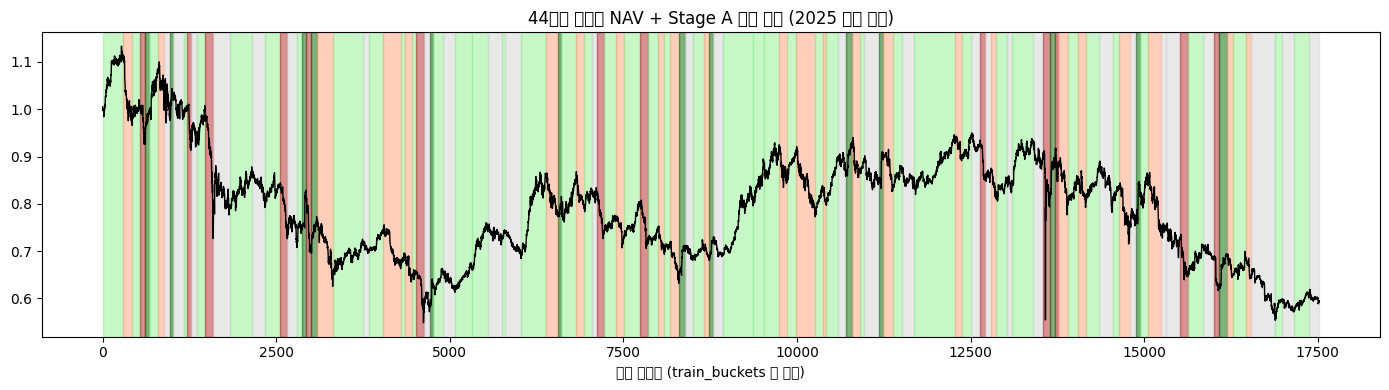

In [ ]:
# 44종목 등가중 NAV 곡선 구성 (거래비용 제외 — 시장 자체의 추세 파악용)
eq_ret_per_bucket = np.array([
    np.mean([ret_index.get((sym, b), 0.0) for sym in symbols])
    for b in train_buckets
])
eq_nav = pd.Series(np.cumprod(1 + eq_ret_per_bucket), index=range(len(train_buckets)))

seg = segment_and_label(
    eq_nav, n_labels=N_LABELS, risk_threshold=RISK_THRESHOLD,
    lowpass_window=LOWPASS_WINDOW,
)
print(f"구간 수: {len(seg.chunks)} (평균 길이 {seg.chunks['length'].mean():.0f}버킷 ≈ {seg.chunks['length'].mean()/48:.1f}일)")
print(seg.chunks['regime'].value_counts())

fig, ax = plt.subplots(figsize=(14, 4))
colors = {'bear': 'firebrick', 'pullback': 'lightsalmon', 'sideways': 'lightgray', 'rally': 'lightgreen', 'bull': 'darkgreen'}
for _, row in seg.chunks.iterrows():
    ax.axvspan(row['start_idx'], row['end_idx'], color=colors[row['regime']], alpha=0.5)
ax.plot(eq_nav.values, color='black', lw=1)
ax.set_title('44종목 등가중 NAV + Stage A 레짐 분할 (2025 학습 구간)')
ax.set_xlabel('버킷 인덱스 (train_buckets 내 위치)')
plt.tight_layout()
plt.show()


## 5. Stage B — 레짐 선호도 기반 에이전트 풀 학습

`CryptoPortfolioEnv`를 "청크 단위 에피소드"로 감싼 `ChunkedCryptoPortfolioEnv`를 만든다. `reset()`마다
EarnHFT Eq.4 우선순위(β)로 Stage A의 chunk 하나를 뽑아 그 구간만 진행하고 종료한다. step()/관측/보상
로직은 `CryptoPortfolioEnv`와 완전히 동일 — 에피소드 경계와 시작 구간만 다르다.

`POOL_BETAS`의 각 β로 별도 PPO를 학습해 4개 에이전트 풀을 만든다(β>0: 강세장 선호 구간 위주 학습,
β<0: 약세장 선호 구간 위주 학습).

In [ ]:
class ChunkedCryptoPortfolioEnv(CryptoPortfolioEnv):
    """
    EarnHFT Stage II 이식 — reset()마다 레짐 우선순위(β)로 청크를 샘플링해
    그 구간만 진행하고 종료하는 에피소드형 환경.
    """

    def __init__(self, all_buckets, chunks, beta, risk_threshold=0.2, rng=None, **env_kwargs):
        self.all_buckets = all_buckets
        self.chunks      = chunks.reset_index(drop=True)
        self.beta        = beta
        self.priority    = chunk_sampling_priority(self.chunks, beta, risk_threshold)
        self.rng         = rng or np.random.default_rng()
        super().__init__(buckets=all_buckets[:2], **env_kwargs)  # reset()에서 실제 구간으로 교체됨

    def reset(self, seed=None, options=None):
        idx = self.rng.choice(len(self.chunks), p=self.priority)
        row = self.chunks.iloc[idx]
        self.buckets = self.all_buckets[int(row['start_idx']):int(row['end_idx']) + 1]
        return super().reset(seed=seed, options=options)


# 스모크 테스트: β별로 몇 번 reset해서 실제로 다른 구간이 뽑히는지 확인
_test_env = ChunkedCryptoPortfolioEnv(
    all_buckets=train_buckets, chunks=seg.chunks, beta=90, rng=np.random.default_rng(0), **env_kwargs
)
for _ in range(3):
    _test_env.reset()
    print(f'β=90 샘플 구간: {len(_test_env.buckets)}버킷 ({bucket_to_date(_test_env.buckets[0])} ~ {bucket_to_date(_test_env.buckets[-1])})')


β=90 샘플 구간: 89버킷 (2025-08-12 ~ 2025-08-13)
β=90 샘플 구간: 59버킷 (2025-03-03 ~ 2025-03-04)
β=90 샘플 구간: 59버킷 (2025-01-13 ~ 2025-01-14)


In [ ]:
%%time
POOL_DIR.mkdir(parents=True, exist_ok=True)
pool_models = {}

for pool_i, beta in enumerate(POOL_BETAS):
    print(f'\n=== β={beta} 에이전트 학습 ({POOL_TIMESTEPS_EACH:,} 스텝) ===')
    rng = np.random.default_rng(1000 + pool_i)  # beta가 음수일 수 있어 순번 기반 시드 사용
    chunk_env = Monitor(ChunkedCryptoPortfolioEnv(
        all_buckets=train_buckets, chunks=seg.chunks, beta=beta,
        risk_threshold=RISK_THRESHOLD, rng=rng, **env_kwargs,
    ))
    model = PPO(
        'MlpPolicy', chunk_env,
        learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
        max_grad_norm=0.5, policy_kwargs=dict(net_arch=[512, 256]),
        verbose=0, device='cpu', seed=42,
    )
    model.learn(total_timesteps=POOL_TIMESTEPS_EACH, progress_bar=True)

    save_path = POOL_DIR / f'agent_beta_{beta}.zip'
    model.save(str(save_path))
    pool_models[beta] = model
    print(f'저장: {save_path.name}')

print(f'\n풀 학습 완료: {len(pool_models)}개 에이전트')



=== β=-90 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_-90.zip

=== β=-30 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_-30.zip

=== β=30 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_30.zip

=== β=90 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_90.zip

풀 학습 완료: 4개 에이전트
CPU times: user 1h 8min 3s, sys: 23.1 s, total: 1h 8min 26s
Wall time: 1h 10min 31s


## 6. Stage C — 라우터 학습 (일 단위 풀 선택)

`MacroRouterEnv`는 1일(`ROUTE_BUCKETS`=48버킷) 단위로 풀 중 어느 에이전트에게 그 구간의 트레이딩을
맡길지 선택하는 고수준 환경이다. 포트폴리오 상태(비중·가치)는 내부 `CryptoPortfolioEnv`가 라우팅
구간을 넘나들며 연속으로 유지하고, 저수준 정책(풀 에이전트)만 구간마다 바뀐다. 상태는 최근
`MACRO_WINDOW`(=2일)간의 NAV 변화(EarnHFT의 매크로 OHLC 지표에 대응) — 오라클 레짐 라벨을 직접 넣지
않고 원시 가격 이력만으로 라우터가 스스로 패턴을 학습하게 한다(논문의 Xht도 실제 라벨이 아닌 기술지표).

In [7]:
class MacroRouterEnv(gym.Env):
    """
    EarnHFT Stage III 이식 — 1일 단위로 풀 중 하나를 선택해 그 정책이 해당 구간의
    실제 트레이딩을 대신 수행하도록 하는 고수준 환경.
    """
    metadata = {'render_modes': []}

    def __init__(self, buckets, pool_models, route_buckets=48, macro_window=96, **env_kwargs):
        super().__init__()
        self.pool_models    = list(pool_models)
        self.route_buckets  = route_buckets
        self.macro_window   = macro_window
        self.inner           = CryptoPortfolioEnv(buckets=buckets, **env_kwargs)
        self.action_space      = spaces.Discrete(len(self.pool_models))
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(macro_window + 4,), dtype=np.float32)
        self._nav_history = []

    def _macro_obs(self):
        hist = self._nav_history[-self.macro_window:]
        if len(hist) < self.macro_window:
            hist = [1.0] * (self.macro_window - len(hist)) + hist
        recent = np.array(hist, dtype=np.float32)
        ret = np.diff(recent) if len(recent) > 1 else np.zeros(1, dtype=np.float32)
        stats = np.array([
            recent[-1] - recent[0],
            float(ret.std()),
            float(ret.mean()),
            self.inner.t / max(len(self.inner.buckets) - 1, 1),
        ], dtype=np.float32)
        return np.concatenate([recent, stats]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.inner.reset(seed=seed)
        self._nav_history = []
        return self._macro_obs(), {}

    def step(self, action):
        model = self.pool_models[int(action)]
        block_reward = 0.0
        done_inner = False
        for _ in range(self.route_buckets):
            obs = self.inner._get_obs()
            a, _ = model.predict(obs, deterministic=True)
            _, r, done_inner, _, info = self.inner.step(a)
            block_reward += r
            self._nav_history.append(info['portfolio_value'])
            if done_inner:
                break
        done = done_inner or self.inner.t >= len(self.inner.buckets) - 1
        info = {'portfolio_value': self.inner.portfolio_value}
        return self._macro_obs(), block_reward, done, False, info


# 스모크 테스트 — pool_models가 아직 없는 세션(§5를 건너뛰고 §5-로더만 나중에 실행하는 복구 경로)에서도
# 이 셀이 클래스 정의만은 항상 성공하도록 방어.
if 'pool_models' in globals() and pool_models:
    _router_probe = MacroRouterEnv(
        buckets=train_buckets[:500], pool_models=list(pool_models.values()),
        route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
    )
    obs, _ = _router_probe.reset()
    print('router obs shape:', obs.shape)
    obs, r, done, _, info = _router_probe.step(0)
    print('1스텝 후 reward:', r, 'portfolio_value:', info['portfolio_value'])
else:
    print('MacroRouterEnv 클래스 정의 완료 (pool_models 없음 — 스모크 테스트 생략, §5-로더 실행 후 계속 진행)')


MacroRouterEnv 클래스 정의 완료 (pool_models 없음 — 스모크 테스트 생략, §5-로더 실행 후 계속 진행)


In [ ]:
%%time
router_env = Monitor(MacroRouterEnv(
    buckets=train_buckets, pool_models=[pool_models[b] for b in POOL_BETAS],
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
))

router = DQN(
    'MlpPolicy', router_env,
    learning_rate=1e-3, buffer_size=20_000, learning_starts=500,
    batch_size=64, gamma=0.95, train_freq=1, target_update_interval=200,
    exploration_fraction=0.3, exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[128, 64]),
    verbose=1, device='cpu', seed=42,
)
router.learn(total_timesteps=ROUTER_TOTAL_TIMESTEPS, progress_bar=True)

router_path = MODEL_DIR / 'crypto_hrl_router.zip'
router.save(str(router_path))
print(f'라우터 저장: {router_path.name}')


Output()

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 365      |
|    ep_rew_mean      | -1.19    |
|    exploration_rate | 0.769    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 14       |
|    time_elapsed     | 102      |
|    total_timesteps  | 1460     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.000444 |
|    n_updates        | 959      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 365      |
|    ep_rew_mean      | -1.2     |
|    exploration_rate | 0.538    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 14       |
|    time_elapsed     | 206      |
|    total_timesteps  | 2920     |
| train/              |          |
|    learning_rate    | 0.001    |
|  

라우터 저장: crypto_hrl_router.zip
CPU times: user 23min 12s, sys: 8.11 s, total: 23min 20s
Wall time: 24min 7s


In [8]:
# 진단 재실행용 로더 — 런타임이 끊겨 pool_models/router가 메모리에 없어도
# 재학습 없이 저장된 모델만 불러와 백테스트를 이어서 할 수 있게 함.
# (풀 학습을 방금 마친 세션이면 이미 메모리에 있으므로 그대로 재사용됨)
if 'pool_models' not in globals() or not pool_models:
    pool_models = {b: PPO.load(str(POOL_DIR / f'agent_beta_{b}.zip')) for b in POOL_BETAS}
    print('풀 에이전트 로드 완료:', list(pool_models.keys()))
if 'router' not in globals():
    router = DQN.load(str(MODEL_DIR / 'crypto_hrl_router.zip'))
    print('라우터 로드 완료')


풀 에이전트 로드 완료: [-90, -30, 30, 90]
라우터 로드 완료


## 7. 최종 백테스트 — 라우터+풀 vs 단일 PPO vs 등가중

In [9]:
def compute_perf(values, steps_per_year=48 * 365):
    """성과 지표 계산 — 30분봉·24/7 시장 기준 연환산(48스텝/일)"""
    rets       = np.diff(values) / values[:-1]
    total_ret  = values[-1] / values[0] - 1
    annual_ret = (1 + total_ret) ** (steps_per_year / len(rets)) - 1
    sharpe     = rets.mean() / (rets.std() + 1e-8) * np.sqrt(steps_per_year)
    max_dd     = ((values / np.maximum.accumulate(values)) - 1).min()
    return {
        '총 수익률':    f'{total_ret*100:.2f}%',
        '연환산 수익률': f'{annual_ret*100:.2f}%',
        'Sharpe':      f'{sharpe:.3f}',
        'MDD':         f'{max_dd*100:.2f}%',
    }


def turnover_stats(turnovers, tc=TC):
    """진단용 — 스텝별 비중 변화량(턴오버)과 거래비용 드래그 요약."""
    t = np.asarray(turnovers, dtype=np.float64)
    cost_factors = 1 - tc * t
    cost_drag = 1 - np.prod(cost_factors)  # 거래비용만으로 누적 손실된 비율
    return {
        '평균 턴오버/스텝':   f'{t.mean()*100:.1f}%',
        '중앙값 턴오버/스텝':  f'{np.median(t)*100:.1f}%',
        '스텝당 평균 거래비용': f'{(tc * t).mean()*100:.4f}%',
        '누적 거래비용 드래그(총자산 대비)': f'{cost_drag*100:.2f}%',
    }


def run_backtest(env, model, deterministic=True):
    obs, _ = env.reset()
    done, values = False, [1.0]
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, _, done, _, info = env.step(action)
        values.append(info['portfolio_value'])
    return np.array(values), list(env.turnover_history)


def equal_weight_backtest(env):
    obs, _ = env.reset()
    done, values = False, [1.0]
    action = np.ones(env.n_assets, dtype=np.float32) / env.n_assets
    while not done:
        obs, _, done, _, info = env.step(action)
        values.append(info['portfolio_value'])
    return np.array(values), list(env.turnover_history)


print('테스트 구간에서 라우터+풀 시스템 실행 중...')
router_test_env = MacroRouterEnv(
    buckets=test_buckets, pool_models=[pool_models[b] for b in POOL_BETAS],
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
)
obs, _ = router_test_env.reset()
done, chosen = False, []
while not done:
    action, _ = router.predict(obs, deterministic=True)
    chosen.append(int(action))
    obs, _, done, _, info = router_test_env.step(action)

hrl_values = np.array(router_test_env.inner.value_history)
hrl_turnovers = list(router_test_env.inner.turnover_history)
print('라우터 선택 분포(β):', {POOL_BETAS[k]: v for k, v in pd.Series(chosen).value_counts().to_dict().items()})

comparison = {}
turnover_comparison = {}
if ORIG_PPO_PATH.exists():
    print('기존 단일 PPO(crypto_ppo_portfolio.zip) 로드해 비교에 포함...')
    orig_ppo = PPO.load(str(ORIG_PPO_PATH))
    ppo_values, ppo_turnovers = run_backtest(CryptoPortfolioEnv(test_buckets, **env_kwargs), orig_ppo)
    comparison['단일 PPO (기존)'] = compute_perf(ppo_values)
    turnover_comparison['단일 PPO (기존)'] = turnover_stats(ppo_turnovers)
else:
    print('crypto_ppo_portfolio.zip 없음 — 단일 PPO 비교 생략')

ew_values, ew_turnovers = equal_weight_backtest(CryptoPortfolioEnv(test_buckets, **env_kwargs))
comparison['등가중 벤치마크']    = compute_perf(ew_values)
turnover_comparison['등가중 벤치마크'] = turnover_stats(ew_turnovers)

comparison['EarnHFT식 라우터+풀'] = compute_perf(hrl_values)
turnover_comparison['EarnHFT식 라우터+풀'] = turnover_stats(hrl_turnovers)

perf_df = pd.DataFrame(comparison).T
print()
print(perf_df.to_string())
perf_df.to_csv(CRYPTO_DIR / 'crypto_hrl_performance.csv', encoding='utf-8-sig')
print('\n저장 완료: crypto_hrl_performance.csv')

turnover_df = pd.DataFrame(turnover_comparison).T
print()
print('--- 턴오버/거래비용 진단 ---')
print(turnover_df.to_string())
turnover_df.to_csv(CRYPTO_DIR / 'crypto_hrl_turnover_diag.csv', encoding='utf-8-sig')
print('\n저장 완료: crypto_hrl_turnover_diag.csv')


테스트 구간에서 라우터+풀 시스템 실행 중...
라우터 선택 분포(β): {30: 123, -90: 56, -30: 11, 90: 5}
기존 단일 PPO(crypto_ppo_portfolio.zip) 로드해 비교에 포함...

                  총 수익률  연환산 수익률  Sharpe      MDD
단일 PPO (기존)     -75.68%  -92.99%  -4.209  -79.04%
등가중 벤치마크          2.66%    5.05%   0.367  -40.09%
EarnHFT식 라우터+풀  -32.24%  -51.90%  -1.107  -50.04%

저장 완료: crypto_hrl_performance.csv

--- 턴오버/거래비용 진단 ---
               평균 턴오버/스텝 중앙값 턴오버/스텝 스텝당 평균 거래비용 누적 거래비용 드래그(총자산 대비)
단일 PPO (기존)        14.4%      12.3%     0.0144%              73.98%
등가중 벤치마크            0.0%       0.0%     0.0000%               0.00%
EarnHFT식 라우터+풀      5.4%       4.0%     0.0054%              39.81%

저장 완료: crypto_hrl_turnover_diag.csv


## 8. 시각화

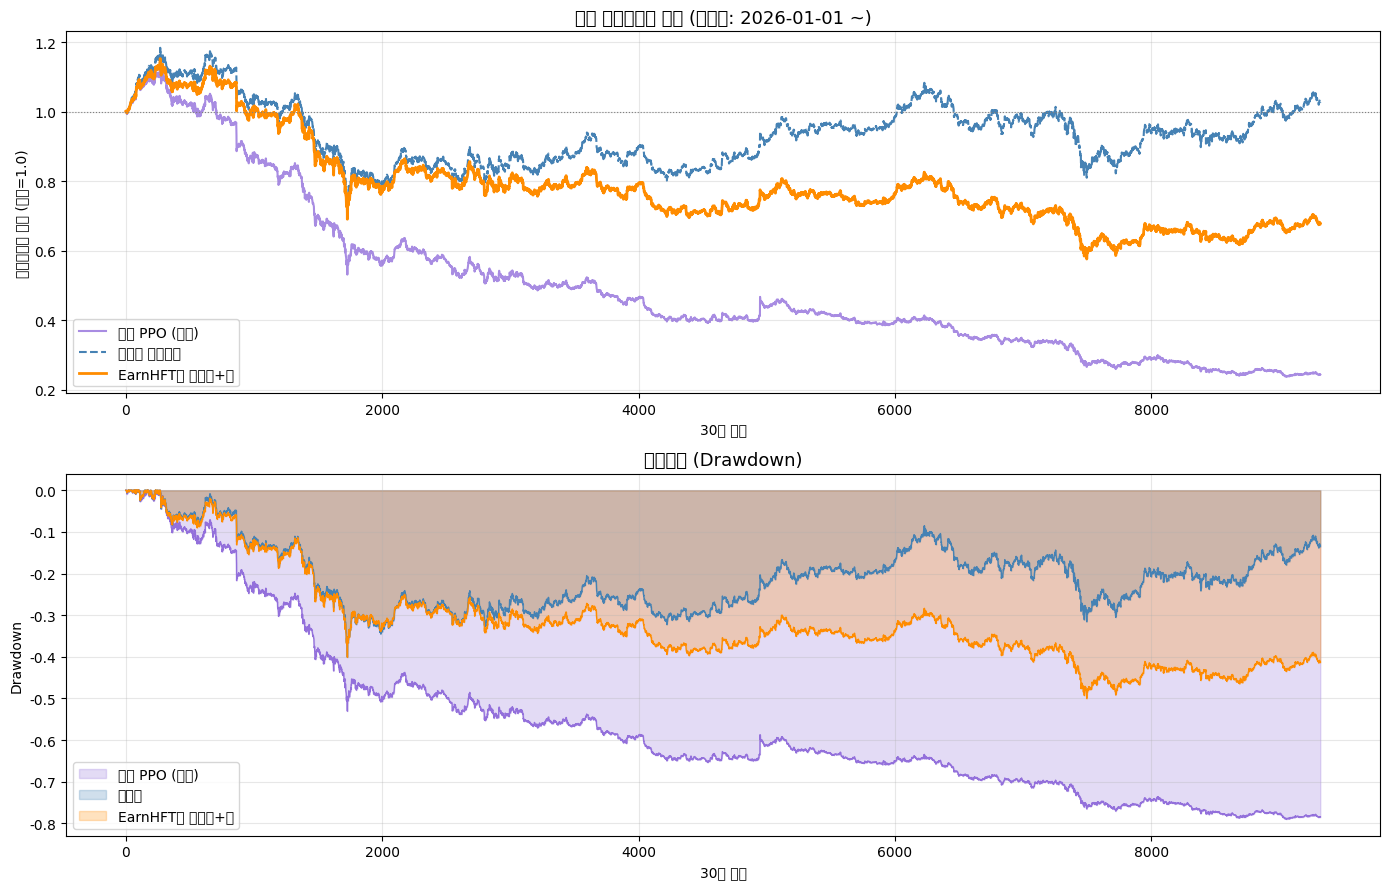

저장 완료: crypto_hrl_backtest.png

▶ 이 노트북은 EarnHFT Stage II(에이전트 풀)+III(라우터)를 이식했고 Stage I(Q-teacher)은
  연속 포트폴리오 액션 공간에 대응되지 않아 제외했다 — 보고서 한계점 절에 명시할 것.
▶ 다음 단계: 결과가 개선되면 live_trading_loop_binance.py에 라우터+풀 기반 PolicyAdapter 구현 검토


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
if ORIG_PPO_PATH.exists():
    ax.plot(ppo_values, label='단일 PPO (기존)', color='mediumpurple', lw=1.5, alpha=0.8)
ax.plot(ew_values,  label='등가중 벤치마크', color='steelblue', lw=1.5, ls='--')
ax.plot(hrl_values, label='EarnHFT식 라우터+풀', color='darkorange', lw=2)
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'누적 포트폴리오 가치 (테스트: {RL_TEST_START} ~)', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.set_xlabel('30분 스텝')
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
series_list = [(ew_values, '등가중', 'steelblue'), (hrl_values, 'EarnHFT식 라우터+풀', 'darkorange')]
if ORIG_PPO_PATH.exists():
    series_list.insert(0, (ppo_values, '단일 PPO (기존)', 'mediumpurple'))
for vals, label, color in series_list:
    dd = (vals / np.maximum.accumulate(vals)) - 1
    ax2.fill_between(range(len(dd)), dd, 0, alpha=0.25, color=color, label=label)
    ax2.plot(dd, color=color, lw=1)
ax2.set_title('드로다운 (Drawdown)', fontsize=13)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('30분 스텝')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

print('저장 완료: crypto_hrl_backtest.png')
print()
print('▶ 이 노트북은 EarnHFT Stage II(에이전트 풀)+III(라우터)를 이식했고 Stage I(Q-teacher)은')
print('  연속 포트폴리오 액션 공간에 대응되지 않아 제외했다 — 보고서 한계점 절에 명시할 것.')
print('▶ 다음 단계: 결과가 개선되면 live_trading_loop_binance.py에 라우터+풀 기반 PolicyAdapter 구현 검토')


## 9. 스무딩 재백테스트 — 재학습 없이 관성 스무딩(α)만 적용

§7 진단 결과 라우터+풀의 손실(-32.2%)은 거의 전부 거래비용 드래그(-39.8%)였다. 비용 전 기준으로 역산하면
약 +12.6%로 등가중(+2.7%)을 이긴다 — 즉 종목 선택 알파는 있는데 스텝당 5.4% 턴오버가 그것을 태워버리는 구조.

여기서는 **학습된 모델을 그대로 두고** 실행 시 비중 갱신만 `w_new = (1-α)·w_old + α·softmax(action)`으로
바꿔 턴오버를 구조적으로 제한한다(α가 작을수록 관성↑, 턴오버는 대략 α에 비례해 감소). 이 스윕으로 확인할 것:

1. **알파가 스무딩을 견디는가** — α를 줄여도 비용 전 수익률이 유지되면 신호가 저빈도에서도 유효하다는 뜻.
   그 경우 스무딩을 학습 환경에 넣고 재학습하는 것이 다음 단계.
2. **최적 α 근방** — 비용 후 수익률이 가장 좋은 α가 실전 리밸런싱 강도의 출발점.

α=1.0(스무딩 없음)이 §7과 동일 조건의 기준선이다. **재학습·§7 재실행 모두 불필요** — 새 세션이라면
§1~§3 데이터·환경 셀 → §7 위의 모델 로더 셀 → §6의 `MacroRouterEnv` 클래스 셀(로더 이후에 실행해야
스모크 테스트가 pool_models를 찾음) 순으로 실행한 뒤 아래 셀을 실행하면 된다.

HRL α=1.0 (스무딩 없음) 실행 중...
HRL α=0.3 실행 중...
HRL α=0.15 실행 중...
HRL α=0.05 실행 중...
HRL α=0.03 실행 중...
HRL α=0.02 실행 중...
HRL α=0.01 실행 중...

                   총 수익률(비용 후) 총 수익률(비용 전)      연환산  Sharpe      MDD 평균 턴오버/스텝 누적 비용 드래그
등가중 벤치마크                 2.66%       2.66%    5.05%   0.367  -40.09%     0.00%     0.00%
HRL α=1.0 (스무딩 없음)     -32.24%      12.57%  -51.90%  -1.107  -50.04%     5.45%    39.81%
HRL α=0.3              -14.27%      11.57%  -25.14%  -0.284  -38.62%     2.83%    23.16%
HRL α=0.15              -3.94%      11.47%   -7.28%   0.122  -37.48%     1.60%    13.82%
HRL α=0.05               6.41%      12.58%   12.39%   0.485  -36.71%     0.61%     5.49%
HRL α=0.03               8.57%      12.58%   16.71%   0.557  -36.57%     0.39%     3.56%
HRL α=0.02               9.76%      12.55%   19.14%   0.596  -36.51%     0.27%     2.48%
HRL α=0.01              11.05%      12.54%   21.79%   0.638  -36.47%     0.14%     1.32%

비용 후 최고 α = 0.01 (총 수익률 11.05%) → §10 재학습에 사용
저장 완료: cryp

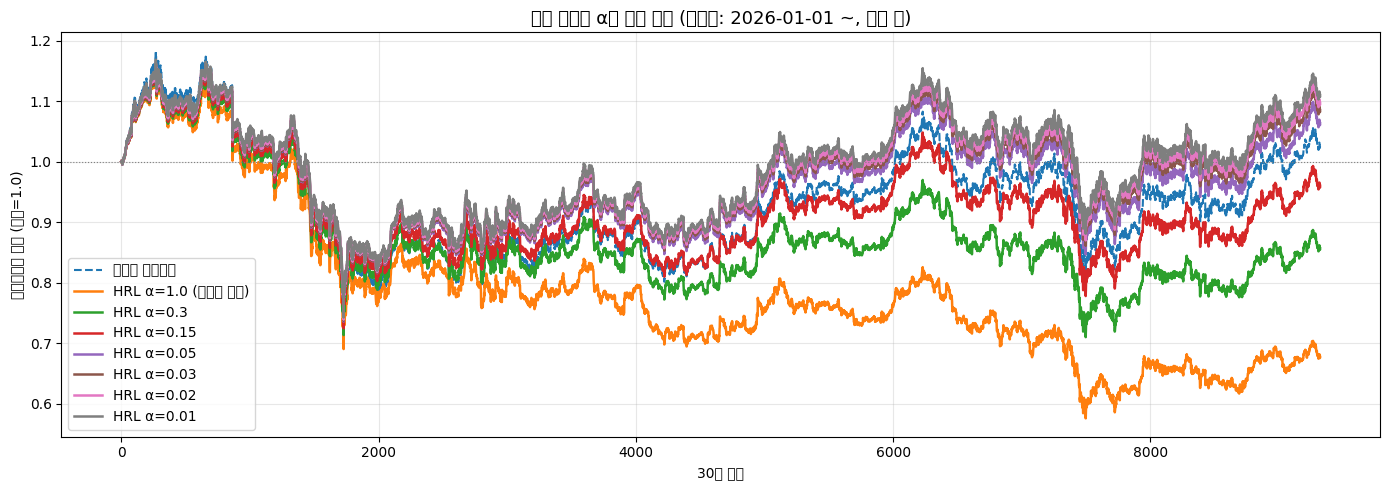

CPU times: user 1min 17s, sys: 87.6 ms, total: 1min 17s
Wall time: 1min 22s


In [10]:
%%time
# 관성 스무딩 스윕 — 학습된 모델은 그대로 두고 실행 단계의 비중 갱신만
#   w_new = (1-α)·w_old + α·softmax(action)
# 으로 바꾼다. softmax(log w) = w 이므로 log(w_new)를 action으로 넘기면
# env 내부 softmax가 w_new를 정확히 복원한다(환경 코드 수정 불필요).
# α=1.0은 스무딩 없음 → §7과 동일 조건의 기준선.
# 1차 스윕(0.3/0.15/0.05)에서 개선이 α=0.05까지 단조증가 → 0.03/0.02/0.01 추가해 최적점 탐색.

SMOOTH_ALPHAS = [1.0, 0.3, 0.15, 0.05, 0.03, 0.02, 0.01]


def _softmax_np(a):
    e = np.exp(a - a.max())
    return e / e.sum()


def run_hrl_smoothed(alpha):
    """라우터+풀 시스템을 테스트 구간에서 실행하되 저수준 비중에 관성 스무딩 적용.
    반환: (비용 후 NAV, 비용 전 NAV, 턴오버 리스트)"""
    env = MacroRouterEnv(
        buckets=test_buckets, pool_models=[pool_models[b] for b in POOL_BETAS],
        route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
    )
    obs, _ = env.reset()
    inner = env.inner
    gross, g = [1.0], 1.0
    done = False
    while not done:
        r_action, _ = router.predict(obs, deterministic=True)
        model = env.pool_models[int(r_action)]
        done_inner = False
        for _ in range(env.route_buckets):
            a, _ = model.predict(inner._get_obs(), deterministic=True)
            w = (1 - alpha) * inner.weights + alpha * _softmax_np(a)
            _, _, done_inner, _, info = inner.step(np.log(w))
            env._nav_history.append(info['portfolio_value'])
            g *= 1 + info['port_ret']
            gross.append(g)
            if done_inner:
                break
        obs = env._macro_obs()
        done = done_inner or inner.t >= len(inner.buckets) - 1
    return np.array(inner.value_history), np.array(gross), list(inner.turnover_history)


def smooth_perf_row(net, gross, turnovers, steps_per_year=48 * 365):
    rets   = np.diff(net) / net[:-1]
    ann    = net[-1] ** (steps_per_year / len(rets)) - 1
    sharpe = rets.mean() / (rets.std() + 1e-8) * np.sqrt(steps_per_year)
    mdd    = ((net / np.maximum.accumulate(net)) - 1).min()
    t      = np.asarray(turnovers, dtype=np.float64)
    return {
        '총 수익률(비용 후)': f'{(net[-1]-1)*100:.2f}%',
        '총 수익률(비용 전)': f'{(gross[-1]-1)*100:.2f}%',
        '연환산':           f'{ann*100:.2f}%',
        'Sharpe':          f'{sharpe:.3f}',
        'MDD':             f'{mdd*100:.2f}%',
        '평균 턴오버/스텝':    f'{t.mean()*100:.2f}%',
        '누적 비용 드래그':    f'{(1 - np.prod(1 - TC*t))*100:.2f}%',
    }


smooth_results, smooth_curves = {}, {}

# 참조용 등가중 (모델 predict 없이 즉시 계산)
_ew_env = CryptoPortfolioEnv(test_buckets, **env_kwargs)
_ew_env.reset()
_ew_a = np.ones(_ew_env.n_assets, dtype=np.float32) / _ew_env.n_assets
_ew_gross, _g, done = [1.0], 1.0, False
while not done:
    _, _, done, _, info = _ew_env.step(_ew_a)
    _g *= 1 + info['port_ret']
    _ew_gross.append(_g)
smooth_results['등가중 벤치마크'] = smooth_perf_row(
    np.array(_ew_env.value_history), np.array(_ew_gross), _ew_env.turnover_history)
smooth_curves['등가중 벤치마크'] = np.array(_ew_env.value_history)

_net_by_alpha = {}
for alpha in SMOOTH_ALPHAS:
    label = 'HRL α=1.0 (스무딩 없음)' if alpha == 1.0 else f'HRL α={alpha}'
    print(f'{label} 실행 중...')
    net, gross, turns = run_hrl_smoothed(alpha)
    smooth_results[label] = smooth_perf_row(net, gross, turns)
    smooth_curves[label]  = net
    _net_by_alpha[alpha]  = net[-1]

BEST_ALPHA = max((a for a in _net_by_alpha if a < 1.0), key=lambda a: _net_by_alpha[a])

smooth_df = pd.DataFrame(smooth_results).T
print()
print(smooth_df.to_string())
print(f'\n비용 후 최고 α = {BEST_ALPHA} (총 수익률 {(_net_by_alpha[BEST_ALPHA]-1)*100:.2f}%) → §10 재학습에 사용')
smooth_df.to_csv(CRYPTO_DIR / 'crypto_hrl_smoothing_sweep.csv', encoding='utf-8-sig')
print('저장 완료: crypto_hrl_smoothing_sweep.csv')

fig, ax = plt.subplots(figsize=(14, 5))
for label, curve in smooth_curves.items():
    lw, ls = (1.5, '--') if '등가중' in label else (1.8, '-')
    ax.plot(curve, label=label, lw=lw, ls=ls)
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'관성 스무딩 α별 누적 가치 (테스트: {RL_TEST_START} ~, 비용 후)', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.set_xlabel('30분 스텝')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_smoothing_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. v2 재학습 — 스무딩을 학습 환경에 내장 + 라우터에 시장 피처 추가

§9에서 확인한 것: **비용 전 알파(+11.5~12.6%)는 α와 무관하게 유지**된다. 즉 풀 에이전트의 신호는
30분 단위 반응이 아니라 수일 단위의 느린 종목 선택이고, 스무딩은 알파를 깎지 않으면서 비용만 줄인다.
다만 §9는 "학습 때와 다른 실행 규칙"을 사후에 끼워 넣은 것이라 이론적으로 어색하다 — 여기서는
스무딩을 **환경 dynamics 자체에 내장**해 에이전트가 관성 있는 세계에 맞춰 학습하게 한다.

v1 대비 바뀌는 것 두 가지:

1. **`SmoothStepMixin`** — 모든 학습/평가 환경의 `step()`이 `w_new = (1-α)·w_old + α·softmax(action)`을
   적용. 풀 에이전트는 이제 자신의 행동이 천천히 반영되는 세계에서 크레딧을 학습한다.
2. **`MacroRouterEnvV2`** — §7 진단에서 라우터가 테스트 기간의 63%를 β=30 하나만 고른 원인은
   관측이 자기 NAV뿐이라 시장 레짐을 볼 수 없었기 때문. v2는 등가중 시장 수익률 창(2일)과
   요약 통계를 관측에 추가한다. RetTarget_6b는 forward 수익률이므로 시점 t 관측에는
   t-1 이하 버킷 값만 사용해 look-ahead를 차단한다.

**실행 순서(새 세션 기준)**: §1~§4 전부(레짐 분할 필요) → §5·§6의 클래스 셀(학습 셀은 건너뜀)
→ §7 위 모델 로더 → §9(BEST_ALPHA 산출, ~2분) → §10 아래 셀들 순서대로.
학습 시간은 풀 4개 ≈ 75분 + 라우터 ≈ 25분. 산출물은 `agent_v2_beta_*.zip`,
`crypto_hrl_router_v2.zip`, `crypto_hrl_v2_performance.csv`, `crypto_hrl_v2_backtest.png`.


In [ ]:
# §10-A — 스무딩 내장 환경(v2) + 시장 피처 라우터 정의
SMOOTH_ALPHA_TRAIN = 0.05
if 'BEST_ALPHA' in globals():
    # α가 너무 작으면 행동→보상 신호가 약해져 PPO 학습이 어려우므로 하한 0.03
    SMOOTH_ALPHA_TRAIN = max(BEST_ALPHA, 0.03)
print(f'학습용 스무딩 계수 α = {SMOOTH_ALPHA_TRAIN}')


class SmoothStepMixin:
    """step()에서 w_new = (1-α)·w_old + α·softmax(action)을 적용한 뒤 log(w_new)를
    부모 step에 넘긴다 — 부모의 softmax가 w_new를 그대로 복원하므로 부모 코드 수정 불필요."""
    smooth_alpha = 0.05

    def step(self, action):
        target = np.exp(action - np.max(action))
        target = target / target.sum()
        w = (1 - self.smooth_alpha) * self.weights + self.smooth_alpha * target
        return super().step(np.log(w))


class SmoothedPortfolioEnv(SmoothStepMixin, CryptoPortfolioEnv):
    def __init__(self, *args, smooth_alpha=0.05, **kwargs):
        super().__init__(*args, **kwargs)
        self.smooth_alpha = smooth_alpha


class SmoothedChunkedEnv(SmoothStepMixin, ChunkedCryptoPortfolioEnv):
    def __init__(self, *args, smooth_alpha=0.05, **kwargs):
        super().__init__(*args, **kwargs)
        self.smooth_alpha = smooth_alpha


# 라우터 관측용 등가중 시장 수익률. RetTarget_6b는 forward 수익률(버킷 b 값 = b→b+1 구간)이므로
# 시점 t의 관측에는 t-1 이하 버킷 값만 넣는다 — look-ahead 차단은 _macro_obs의 [:t] 슬라이스가 담당.
ew_ret_by_bucket = {
    b: float(np.mean([ret_index.get((s, b), 0.0) for s in symbols]))
    for b in all_buckets
}


class MacroRouterEnvV2(MacroRouterEnv):
    """v2 — (1) 내부 환경에 관성 스무딩 내장, (2) 관측에 등가중 시장 수익률 창 추가."""

    def __init__(self, buckets, pool_models, ew_ret_by_bucket, smooth_alpha=0.05,
                 route_buckets=48, macro_window=96, **env_kwargs):
        super().__init__(buckets, pool_models, route_buckets=route_buckets,
                         macro_window=macro_window, **env_kwargs)
        self.inner  = SmoothedPortfolioEnv(buckets=buckets, smooth_alpha=smooth_alpha, **env_kwargs)
        self.ew_ret = ew_ret_by_bucket
        self.observation_space = spaces.Box(
            -np.inf, np.inf, shape=(macro_window * 2 + 8,), dtype=np.float32)

    def _macro_obs(self):
        base = super()._macro_obs()   # 자기 NAV 창 + 4개 통계
        t = self.inner.t
        win = np.zeros(self.macro_window, dtype=np.float32)
        past = [self.ew_ret.get(b, 0.0) for b in self.inner.buckets[max(0, t - self.macro_window):t]]
        if past:
            win[-len(past):] = past
        win *= 100.0   # 30분 수익률(~1e-3) 스케일 보정
        day = win[-self.route_buckets:]
        stats = np.array([win.mean(), win.std(), day.mean(), day.std()], dtype=np.float32)
        return np.concatenate([base, win, stats]).astype(np.float32)


# 스모크 테스트 — v1 풀로 관측 shape와 스무딩 적용 여부 확인
_v2_probe = MacroRouterEnvV2(
    buckets=train_buckets[:500], pool_models=[pool_models[b] for b in POOL_BETAS],
    ew_ret_by_bucket=ew_ret_by_bucket, smooth_alpha=SMOOTH_ALPHA_TRAIN,
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
)
obs, _ = _v2_probe.reset()
print('v2 router obs shape:', obs.shape)
obs, r, done, _, info = _v2_probe.step(0)
print(f'1스텝(=1일) 후 reward: {r:.5f} | 내부 턴오버(스무딩 적용): '
      f'{np.mean(_v2_probe.inner.turnover_history)*100:.2f}%/스텝')


학습용 스무딩 계수 α = 0.03
v2 router obs shape: (200,)
1스텝(=1일) 후 reward: 0.03253 | 내부 턴오버(스무딩 적용): 0.79%/스텝


In [ ]:
%%time
# §10-B — 스무딩 내장 환경에서 풀 재학습 (구조·하이퍼파라미터는 §5와 동일, 환경만 v2)
pool_v2 = {}

for pool_i, beta in enumerate(POOL_BETAS):
    print(f'\n=== [v2] β={beta} 에이전트 학습 ({POOL_TIMESTEPS_EACH:,} 스텝, α={SMOOTH_ALPHA_TRAIN}) ===')
    rng = np.random.default_rng(2000 + pool_i)
    chunk_env = Monitor(SmoothedChunkedEnv(
        all_buckets=train_buckets, chunks=seg.chunks, beta=beta,
        risk_threshold=RISK_THRESHOLD, rng=rng, smooth_alpha=SMOOTH_ALPHA_TRAIN, **env_kwargs,
    ))
    model = PPO(
        'MlpPolicy', chunk_env,
        learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
        max_grad_norm=0.5, policy_kwargs=dict(net_arch=[512, 256]),
        verbose=0, device='cpu', seed=42,
    )
    model.learn(total_timesteps=POOL_TIMESTEPS_EACH, progress_bar=True)

    save_path = POOL_DIR / f'agent_v2_beta_{beta}.zip'
    model.save(str(save_path))
    pool_v2[beta] = model
    print(f'저장: {save_path.name}')

print(f'\n[v2] 풀 학습 완료: {len(pool_v2)}개')



=== [v2] β=-90 에이전트 학습 (100,000 스텝, α=0.03) ===


Output()

저장: agent_v2_beta_-90.zip

=== [v2] β=-30 에이전트 학습 (100,000 스텝, α=0.03) ===


Output()

저장: agent_v2_beta_-30.zip

=== [v2] β=30 에이전트 학습 (100,000 스텝, α=0.03) ===


Output()

저장: agent_v2_beta_30.zip

=== [v2] β=90 에이전트 학습 (100,000 스텝, α=0.03) ===


Output()

저장: agent_v2_beta_90.zip

[v2] 풀 학습 완료: 4개
CPU times: user 1h 7min 16s, sys: 21.5 s, total: 1h 7min 38s
Wall time: 1h 9min 25s


In [ ]:
%%time
# §10-C — 시장 피처 라우터 재학습. v1에서는 에피소드 리워드가 거래비용에 지배돼(-1.05/년)
# 라우터가 배울 것이 없었다 — v2는 스무딩으로 비용이 억제돼 순수 배분 성과가 신호가 된다.
router_v2_env = Monitor(MacroRouterEnvV2(
    buckets=train_buckets, pool_models=[pool_v2[b] for b in POOL_BETAS],
    ew_ret_by_bucket=ew_ret_by_bucket, smooth_alpha=SMOOTH_ALPHA_TRAIN,
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
))

router_v2 = DQN(
    'MlpPolicy', router_v2_env,
    learning_rate=1e-3, buffer_size=20_000, learning_starts=500,
    batch_size=64, gamma=0.95, train_freq=1, target_update_interval=200,
    exploration_fraction=0.3, exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[128, 64]),
    verbose=1, device='cpu', seed=42,
)
router_v2.learn(total_timesteps=ROUTER_TOTAL_TIMESTEPS, progress_bar=True)

router_v2.save(str(MODEL_DIR / 'crypto_hrl_router_v2.zip'))
print('저장: crypto_hrl_router_v2.zip')


Output()

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 365      |
|    ep_rew_mean      | -0.304   |
|    exploration_rate | 0.769    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 13       |
|    time_elapsed     | 104      |
|    total_timesteps  | 1460     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.000191 |
|    n_updates        | 959      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 365      |
|    ep_rew_mean      | -0.3     |
|    exploration_rate | 0.538    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 13       |
|    time_elapsed     | 210      |
|    total_timesteps  | 2920     |
| train/              |          |
|    learning_rate    | 0.001    |
|  

저장: crypto_hrl_router_v2.zip
CPU times: user 23min 25s, sys: 8.14 s, total: 23min 33s
Wall time: 24min 19s


In [ ]:
# §10 진단 재실행용 로더 — 세션이 끊겨도 저장된 v2 모델만 다시 불러오면 백테스트 가능
# (§10-A의 클래스 정의 셀은 먼저 실행돼 있어야 함)
if 'pool_v2' not in globals() or not pool_v2:
    pool_v2 = {b: PPO.load(str(POOL_DIR / f'agent_v2_beta_{b}.zip')) for b in POOL_BETAS}
    print('[v2] 풀 로드 완료:', list(pool_v2.keys()))
if 'router_v2' not in globals():
    router_v2 = DQN.load(str(MODEL_DIR / 'crypto_hrl_router_v2.zip'))
    print('[v2] 라우터 로드 완료')


[v2] 테스트 구간 실행 중...
[v2] 라우터 선택 분포(β): {-30: 142, -90: 35, 90: 13, 30: 5}
v1 + 추론 스무딩 α=0.03 실행 중...

                   총 수익률(비용 후) 총 수익률(비용 전)     연환산 Sharpe      MDD 평균 턴오버/스텝 누적 비용 드래그
등가중 벤치마크                 2.66%       2.66%   5.05%  0.367  -40.09%     0.00%     0.00%
v1 + 추론 스무딩 α=0.03       8.57%      12.58%  16.71%  0.557  -36.57%     0.39%     3.56%
v2 재학습 (α=0.03 내장)      -0.23%       4.08%  -0.44%  0.273  -40.68%     0.45%     4.15%

저장 완료: crypto_hrl_v2_performance.csv


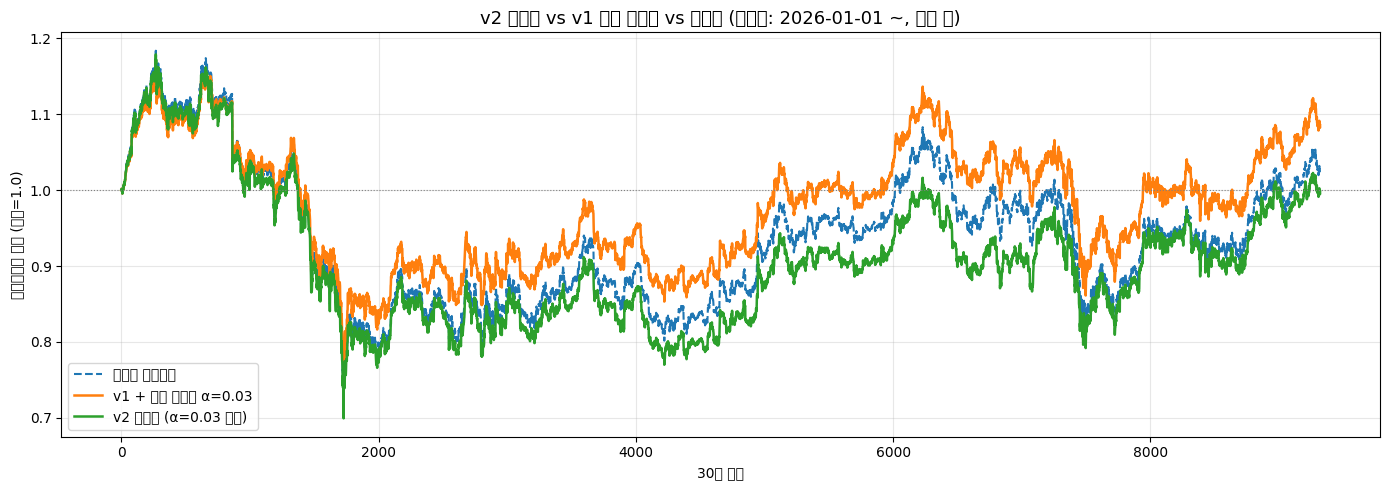

In [ ]:
# §10-D — 최종 비교: v2(스무딩 내장 재학습) vs v1+추론 스무딩 vs 등가중
def _perf_v2(net, gross, turnovers, steps_per_year=48 * 365):
    rets   = np.diff(net) / net[:-1]
    ann    = net[-1] ** (steps_per_year / len(rets)) - 1
    sharpe = rets.mean() / (rets.std() + 1e-8) * np.sqrt(steps_per_year)
    mdd    = ((net / np.maximum.accumulate(net)) - 1).min()
    t      = np.asarray(turnovers, dtype=np.float64)
    return {
        '총 수익률(비용 후)': f'{(net[-1]-1)*100:.2f}%',
        '총 수익률(비용 전)': f'{(gross[-1]-1)*100:.2f}%',
        '연환산':           f'{ann*100:.2f}%',
        'Sharpe':          f'{sharpe:.3f}',
        'MDD':             f'{mdd*100:.2f}%',
        '평균 턴오버/스텝':    f'{t.mean()*100:.2f}%',
        '누적 비용 드래그':    f'{(1 - np.prod(1 - TC*t))*100:.2f}%',
    }


print('[v2] 테스트 구간 실행 중...')
v2_env = MacroRouterEnvV2(
    buckets=test_buckets, pool_models=[pool_v2[b] for b in POOL_BETAS],
    ew_ret_by_bucket=ew_ret_by_bucket, smooth_alpha=SMOOTH_ALPHA_TRAIN,
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
)
obs, _ = v2_env.reset()
done, chosen_v2, v2_gross, g = False, [], [1.0], 1.0
while not done:
    a, _ = router_v2.predict(obs, deterministic=True)
    chosen_v2.append(int(a))
    # env.step과 동일한 저수준 루프 — gross(비용 전) NAV 추적을 위해 수동 진행
    model = v2_env.pool_models[int(a)]
    inner = v2_env.inner
    done_inner = False
    for _ in range(v2_env.route_buckets):
        pa, _ = model.predict(inner._get_obs(), deterministic=True)
        _, _, done_inner, _, info = inner.step(pa)
        v2_env._nav_history.append(info['portfolio_value'])
        g *= 1 + info['port_ret']
        v2_gross.append(g)
        if done_inner:
            break
    obs = v2_env._macro_obs()
    done = done_inner or inner.t >= len(inner.buckets) - 1

v2_net = np.array(v2_env.inner.value_history)
print('[v2] 라우터 선택 분포(β):',
      {POOL_BETAS[k]: v for k, v in pd.Series(chosen_v2).value_counts().to_dict().items()})

final_results, final_curves = {}, {}

# 등가중 벤치마크
_ew = CryptoPortfolioEnv(test_buckets, **env_kwargs)
_ew.reset()
_ewa = np.ones(_ew.n_assets, dtype=np.float32) / _ew.n_assets
_ewg, _gg, d = [1.0], 1.0, False
while not d:
    _, _, d, _, info = _ew.step(_ewa)
    _gg *= 1 + info['port_ret']
    _ewg.append(_gg)
final_results['등가중 벤치마크'] = _perf_v2(np.array(_ew.value_history), np.array(_ewg), _ew.turnover_history)
final_curves['등가중 벤치마크'] = np.array(_ew.value_history)

# v1 + 추론 스무딩 (§9의 run_hrl_smoothed와 v1 모델이 세션에 있으면 포함)
if 'run_hrl_smoothed' in globals() and 'pool_models' in globals() and 'router' in globals():
    _l1 = f'v1 + 추론 스무딩 α={SMOOTH_ALPHA_TRAIN}'
    print(f'{_l1} 실행 중...')
    net1, gross1, turns1 = run_hrl_smoothed(SMOOTH_ALPHA_TRAIN)
    final_results[_l1] = _perf_v2(net1, gross1, turns1)
    final_curves[_l1]  = net1

_l2 = f'v2 재학습 (α={SMOOTH_ALPHA_TRAIN} 내장)'
final_results[_l2] = _perf_v2(v2_net, np.array(v2_gross), v2_env.inner.turnover_history)
final_curves[_l2]  = v2_net

final_df = pd.DataFrame(final_results).T
print()
print(final_df.to_string())
final_df.to_csv(CRYPTO_DIR / 'crypto_hrl_v2_performance.csv', encoding='utf-8-sig')
print('\n저장 완료: crypto_hrl_v2_performance.csv')

fig, ax = plt.subplots(figsize=(14, 5))
for label, curve in final_curves.items():
    lw, ls = (1.5, '--') if '등가중' in label else (1.8, '-')
    ax.plot(curve, label=label, lw=lw, ls=ls)
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'v2 재학습 vs v1 추론 스무딩 vs 등가중 (테스트: {RL_TEST_START} ~, 비용 후)', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.set_xlabel('30분 스텝')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_v2_backtest.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. 전략 고도화 — 현금 게이트·앙상블·포지션 집중 (재학습 없음)

§9~§10 이후 남은 개선 여지 진단:

- **비용은 다 짰다** — α=0.01에서 드래그 1.32%뿐. 추가 이득은 최대 +1.3%p라 비용 쪽은 종료.
- **가장 큰 레버는 MDD(-36.5%)** — softmax 비중은 합이 항상 1이라 전략에 **현금 개념이 없다**.
  2026 1분기 시장 -30% 급락을 100% 투자 상태로 그대로 맞았다. 실현 데이터 기반
  시장 게이트(추세/변동성)로 노출 φ∈[0,1]을 조절하면 MDD·복리 수익 모두 개선 여지.
- **라우터의 기여가 작다** — v1 라우터는 테스트의 63%를 β=30만 선택. 풀 4개의 목표 비중을
  **평균(앙상블)** 하는 편이 더 단순하고 분산도 줄어든다.
- **포지션 집중** — 44종목 분산 비중을 Top-k로 잘라 집중하면 비용 전 알파 자체가 커질 수 있다.

이 셀은 위 세 가지를 **추론 단계에서만** 조합 실험한다(재학습 없음, ~10분). 현금 게이트는
softmax 환경으로 표현이 안 되므로 env.step 대신 동일 회계(수익률·거래비용)를 수동 시뮬레이터로
구현했다. 게이트는 등가중 시장 NAV/변동성의 **실현값(t-1까지)** 만 사용해 look-ahead를 차단한다.

**해석 주의**: ① `등가중+게이트` 대조군과 비교해야 "타이밍 효과"와 "종목선택 알파"를 분리할 수 있다.
② 이 스윕도 테스트 구간에서 구성을 고르는 것이므로 선택 편향이 §9보다 더 쌓인다 — 최종 주장 전에
워크포워드 검증 필수. 실행 전제: §1~§3 + 모델 로더 + §10-A(`ew_ret_by_bucket`) 실행.


등가중 (대조군) 실행 중...
등가중 + 트렌드 게이트 0% 실행 중...
앙상블(풀 평균) 실행 중...
앙상블 + Top10 집중 실행 중...
앙상블 + 트렌드 게이트 50% 실행 중...
앙상블 + 트렌드 게이트 0% 실행 중...
앙상블 + 볼타게팅 40% 실행 중...
앙상블 + Top10 + 트렌드 50% 실행 중...
앙상블 + Top10 + 트렌드 0% + 볼 40% 실행 중...

참고: §9 라우터 + α=0.01 = 비용 후 +11.05% / Sharpe 0.638 / MDD -36.47%
                             총 수익률(비용 후) 총 수익률(비용 전)      연환산  Sharpe      MDD 평균 턴오버/스텝
등가중 (대조군)                          2.66%       2.66%    5.05%   0.367  -40.09%     0.00%
등가중 + 트렌드 게이트 0%                 -32.15%      -6.35%  -51.77%  -2.003  -45.91%     3.46%
앙상블(풀 평균)                          5.52%       6.02%   10.63%   0.457  -39.43%     0.05%
앙상블 + Top10 집중                    20.41%      23.57%   41.79%   0.942  -39.06%     0.28%
앙상블 + 트렌드 게이트 50%                -14.26%       1.08%  -25.12%  -0.560  -32.71%     1.76%
앙상블 + 트렌드 게이트 0%                 -32.05%      -5.99%  -51.63%  -2.113  -45.39%     3.48%
앙상블 + 볼타게팅 40%                     8.97%      13.51%   17.53%   0.608  -25.91%     0.44

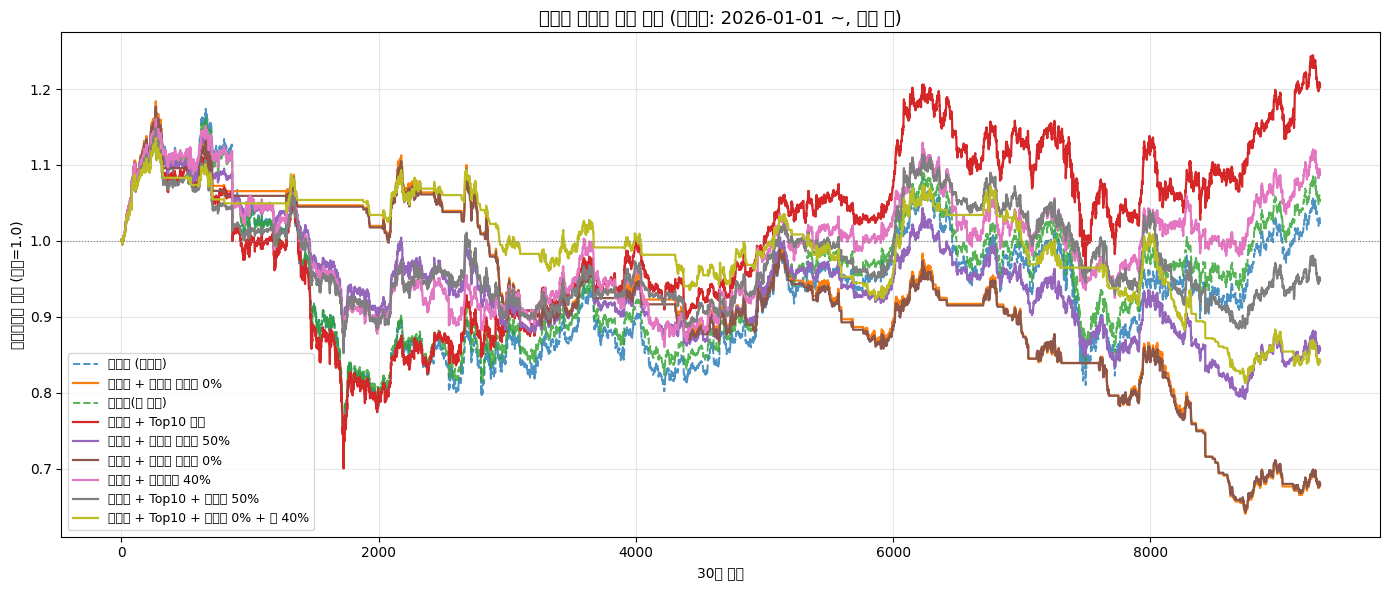

CPU times: user 5min 55s, sys: 205 ms, total: 5min 55s
Wall time: 6min


In [ ]:
%%time
# §11 — 현금 게이트 × 앙상블 × Top-k 집중 조합 스윕 (전부 추론 단계, v1 모델 사용)

OVERLAY_ALPHA  = 0.01        # §9 최적 스무딩
TREND_WINDOW   = 48 * 5      # 시장 NAV 5일 이동평균
VOL_WINDOW     = 96          # 실현변동성 창 = 2일
_ANN           = np.sqrt(48 * 365)


def run_overlay_backtest(models, alpha=OVERLAY_ALPHA, top_k=None, trend=None, vol_target=None):
    """수동 시뮬레이터 — env.step과 동일한 회계에 현금 게이트(노출 φ)를 추가.
    models: 풀 에이전트 리스트(목표 비중을 평균) 또는 None(등가중 유지 = 대조군).
    trend: None 또는 φ_min — 시장 NAV(실현)가 5일 이평 아래면 노출을 φ_min으로.
    vol_target: None 또는 연환산 목표 변동성 — φ = min(1, target/실현변동성).
    반환: (비용 후 NAV, 비용 전 NAV, 턴오버 리스트)"""
    env = CryptoPortfolioEnv(test_buckets, **env_kwargs)   # 임베딩/수익률 헬퍼로만 사용
    n   = env.n_assets
    mkt = np.array([ew_ret_by_bucket.get(b, 0.0) for b in test_buckets])
    # nav_hist[t] = 버킷 t-1까지 실현된 시장 NAV (RetTarget_6b는 forward → [:t] 슬라이스로 look-ahead 차단)
    nav_hist = np.concatenate([[1.0], np.cumprod(1 + mkt[:-1])])

    w, phi = np.ones(n) / n, 1.0
    eff    = w * phi
    V, G   = 1.0, 1.0
    values, gross, turnovers = [1.0], [1.0], []

    for t in range(len(test_buckets) - 1):
        b   = test_buckets[t]
        if models is None:
            target = np.ones(n) / n
        else:
            obs = np.concatenate([env._asset_emb(b), w]).astype(np.float32)
            targets = []
            for m in models:
                a, _ = m.predict(obs, deterministic=True)
                e = np.exp(a - a.max())
                targets.append(e / e.sum())
            target = np.mean(targets, axis=0)
        if top_k is not None:
            cut = np.argsort(target)[:-top_k]
            target = target.copy()
            target[cut] = 0.0
            target = target / target.sum()
        w_new = (1 - alpha) * w + alpha * target

        phi_new = 1.0
        if trend is not None and t >= TREND_WINDOW:
            if nav_hist[t] < nav_hist[t - TREND_WINDOW:t].mean():
                phi_new = min(phi_new, trend)
        if vol_target is not None and t >= VOL_WINDOW:
            rv = mkt[t - VOL_WINDOW:t].std() * _ANN
            if rv > 1e-8:
                phi_new = min(phi_new, vol_target / rv)

        eff_new  = phi_new * w_new
        turnover = float(np.abs(eff_new - eff).sum())
        r        = float((eff_new * env._asset_ret(b)).sum())
        V *= 1 + r - TC * turnover
        G *= 1 + r
        values.append(V); gross.append(G); turnovers.append(turnover)
        w, phi, eff = w_new, phi_new, eff_new

    return np.array(values), np.array(gross), turnovers


def _perf11(net, gross, turnovers, steps_per_year=48 * 365):
    rets   = np.diff(net) / net[:-1]
    ann    = net[-1] ** (steps_per_year / len(rets)) - 1
    sharpe = rets.mean() / (rets.std() + 1e-8) * np.sqrt(steps_per_year)
    mdd    = ((net / np.maximum.accumulate(net)) - 1).min()
    t      = np.asarray(turnovers, dtype=np.float64)
    return {
        '총 수익률(비용 후)': f'{(net[-1]-1)*100:.2f}%',
        '총 수익률(비용 전)': f'{(gross[-1]-1)*100:.2f}%',
        '연환산':           f'{ann*100:.2f}%',
        'Sharpe':          f'{sharpe:.3f}',
        'MDD':             f'{mdd*100:.2f}%',
        '평균 턴오버/스텝':    f'{t.mean()*100:.2f}%',
    }


_pool_list = [pool_models[b] for b in POOL_BETAS]

overlay_configs = {
    '등가중 (대조군)':                     dict(models=None),
    '등가중 + 트렌드 게이트 0%':            dict(models=None, trend=0.0),
    '앙상블(풀 평균)':                     dict(models=_pool_list),
    '앙상블 + Top10 집중':                 dict(models=_pool_list, top_k=10),
    '앙상블 + 트렌드 게이트 50%':           dict(models=_pool_list, trend=0.5),
    '앙상블 + 트렌드 게이트 0%':            dict(models=_pool_list, trend=0.0),
    '앙상블 + 볼타게팅 40%':               dict(models=_pool_list, vol_target=0.40),
    '앙상블 + Top10 + 트렌드 50%':         dict(models=_pool_list, top_k=10, trend=0.5),
    '앙상블 + Top10 + 트렌드 0% + 볼 40%': dict(models=_pool_list, top_k=10, trend=0.0, vol_target=0.40),
}

overlay_results, overlay_curves = {}, {}
for label, cfg in overlay_configs.items():
    print(f'{label} 실행 중...')
    net, gross, turns = run_overlay_backtest(**cfg)
    overlay_results[label] = _perf11(net, gross, turns)
    overlay_curves[label]  = net

overlay_df = pd.DataFrame(overlay_results).T
print()
print('참고: §9 라우터 + α=0.01 = 비용 후 +11.05% / Sharpe 0.638 / MDD -36.47%')
print(overlay_df.to_string())
overlay_df.to_csv(CRYPTO_DIR / 'crypto_hrl_overlay_sweep.csv', encoding='utf-8-sig')
print('\n저장 완료: crypto_hrl_overlay_sweep.csv')

fig, ax = plt.subplots(figsize=(14, 6))
for label, curve in overlay_curves.items():
    if '대조군' in label or label == '앙상블(풀 평균)':
        ax.plot(curve, label=label, lw=1.4, ls='--', alpha=0.8)
    else:
        ax.plot(curve, label=label, lw=1.6)
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'고도화 조합별 누적 가치 (테스트: {RL_TEST_START} ~, 비용 후)', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.set_xlabel('30분 스텝')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_overlay_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. v3 — EarnHFT 원문 충실 재구현 (현금 액션 + Stage II 선별 + Stage III 검증 선택)

§10~§11의 교훈과 논문 원문을 대조해 **논문의 안정화 장치를 정식으로** 이식한다:

| 논문 요소 | v1~v2에서의 누락/약식 | v3에서의 구현 |
|---|---|---|
| 저수준 액션에 position 0(청산) 포함 | softmax 44종목 = 항상 100% 투자 | **현금 자산 추가**(45번째, 수익률 0) — β<0 에이전트가 청산을 학습 가능 |
| Stage II: 다수 후보 → valid 레짐별 선별 | 4개 학습, 선별 없음 | 4β × 체크포인트 5개 = **20 후보** → 2025 Q4 valid 레짐별 최고 선별 |
| Stage III: 라우터도 valid로 선택 | 라우터 1개 무검증 | 체크포인트별 valid 평가 → **최고 라우터 선택** |
| 라우터 관측 = 매크로 지표(Xht) | v1은 자기 NAV만 | 시장 수익률 창 + 통계 (v2 방식 유지) |
| Stage I: Q-teacher | 제외 | **계속 제외** — DP 역산은 단일자산·이산 포지션 전제, 44종목 연속 비중에 불가(한계점 명시) |

추가로 v3는 **선택 편향을 제거**한다: 실행 스무딩 α까지 포함해 모든 선택(에이전트·라우터·α)을
2025 Q4 **valid에서** 하고, 2026 테스트는 최종 구성으로 **단 1회** 실행한다.
풀 학습은 v2 실패 교훈대로 스무딩 없이(전권) 하고, 스무딩은 실행 단계에만 적용한다.

**실행 순서(새 세션)**: §1~§3 → §4의 함수 정의 셀(레짐 분할 함수) → §7 위 v1 로더(§6 스모크
테스트용) → §6 `MacroRouterEnv` 클래스 셀 → §12-A부터 순서대로. §5·§9·§10·§11은 건너뛴다.
소요: Stage B ~75분 + 선별 ~10분 + 라우터 ~30분 + 평가 ~10분 ≈ **총 2시간**.


In [ ]:
# §12-A — 현금 액션 환경 + 2025 내부 train/valid 분할 + v3 라우터 환경 정의
V3_TRAIN_END   = '2025-09-30'   # Stage B 학습: 2025-01 ~ 2025-09
V3_VALID_START = '2025-10-01'   # 선별/검증: 2025-10 ~ 2025-12 (테스트 2026은 최종 1회만)
V3_POOL_DIR    = MODEL_DIR / 'crypto_hrl_pool_v3'
V3_INFER_ALPHA = 0.03           # 선별 단계 실행 스무딩 기본값 — 최종 α는 §12-F에서 valid로 선택

v3_train_buckets = [b for b in train_buckets if bucket_to_date(b) <= V3_TRAIN_END]
v3_valid_buckets = [b for b in train_buckets if bucket_to_date(b) >= V3_VALID_START]
print(f'v3 학습: {bucket_to_date(v3_train_buckets[0])} ~ {bucket_to_date(v3_train_buckets[-1])} ({len(v3_train_buckets):,}스텝)')
print(f'v3 검증: {bucket_to_date(v3_valid_buckets[0])} ~ {bucket_to_date(v3_valid_buckets[-1])} ({len(v3_valid_buckets):,}스텝)')

if 'ew_ret_by_bucket' not in globals():
    ew_ret_by_bucket = {
        b: float(np.mean([ret_index.get((s, b), 0.0) for s in symbols]))
        for b in all_buckets
    }


class CashPortfolioEnv(CryptoPortfolioEnv):
    """44종목 + 현금(마지막 인덱스, 수익률 0) — 논문의 'position 0'(청산) 대응.
    β<0 에이전트가 하락장 대응(포지션 축소)을 액션으로 직접 표현할 수 있게 한다.
    거래비용은 자산 레그 턴오버에만 부과(현금 이동 자체는 무료)."""

    def __init__(self, buckets, **kwargs):
        super().__init__(buckets, **kwargs)
        self.action_space = spaces.Box(-3.0, 3.0, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(
            -np.inf, np.inf, shape=(self.n_assets * self.emb_dim + self.n_assets + 1,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        gym.Env.reset(self, seed=seed)
        self.t                = 0
        self.weights          = np.ones(self.n_assets + 1, dtype=np.float32) / (self.n_assets + 1)
        self.portfolio_value  = 1.0
        self.value_history    = [1.0]
        self.turnover_history = []
        return self._get_obs(), {}

    def step(self, action):
        w = np.exp(action - action.max())
        w = w / w.sum()                                                   # 45-dim, 합=1
        asset_turnover = float(np.abs(w[:-1] - self.weights[:-1]).sum())  # 자산 레그만
        tc_cost = self.tc * asset_turnover

        b        = self.buckets[self.t]
        port_ret = float((w[:-1] * self._asset_ret(b)).sum())             # 현금 수익률 0

        self.portfolio_value *= (1 + port_ret - tc_cost)
        self.weights = w.copy()
        self.value_history.append(self.portfolio_value)
        self.turnover_history.append(asset_turnover)
        self.t += 1

        done = (self.t >= len(self.buckets) - 1)
        info = {'portfolio_value': self.portfolio_value, 'port_ret': port_ret,
                'turnover': asset_turnover, 'tc_cost': tc_cost, 'cash': float(w[-1])}
        return self._get_obs(), float(port_ret - tc_cost), done, False, info


class ChunkedCashEnv(CashPortfolioEnv):
    """β 우선순위 청크 샘플링 에피소드 — §5 ChunkedCryptoPortfolioEnv와 동일 로직, 환경만 현금 버전."""

    def __init__(self, all_buckets, chunks, beta, risk_threshold=0.2, rng=None, **env_kwargs):
        self.all_buckets = all_buckets
        self.chunks      = chunks.reset_index(drop=True)
        self.beta        = beta
        self.priority    = chunk_sampling_priority(self.chunks, beta, risk_threshold)
        self.rng         = rng or np.random.default_rng()
        super().__init__(buckets=all_buckets[:2], **env_kwargs)

    def reset(self, seed=None, options=None):
        idx = self.rng.choice(len(self.chunks), p=self.priority)
        row = self.chunks.iloc[idx]
        self.buckets = self.all_buckets[int(row['start_idx']):int(row['end_idx']) + 1]
        return super().reset(seed=seed, options=options)


class _V3SmoothMixin:
    """실행 스무딩 — 학습이 아닌 실행(라우터 내부·평가)에서만 사용 (v2 실패 교훈)."""
    smooth_alpha = V3_INFER_ALPHA

    def step(self, action):
        target = np.exp(action - np.max(action))
        target = target / target.sum()
        w = (1 - self.smooth_alpha) * self.weights + self.smooth_alpha * target
        return super().step(np.log(w))


class SmoothedCashEnv(_V3SmoothMixin, CashPortfolioEnv):
    def __init__(self, *args, smooth_alpha=V3_INFER_ALPHA, **kwargs):
        super().__init__(*args, **kwargs)
        self.smooth_alpha = smooth_alpha


class CashRouterEnv(MacroRouterEnv):
    """§6 라우터 환경에 (1) 현금 내부 환경 + 실행 스무딩, (2) 시장 수익률 관측(논문 Xht 대응) 추가."""

    def __init__(self, buckets, pool_models, ew_ret_by_bucket, smooth_alpha=V3_INFER_ALPHA,
                 route_buckets=48, macro_window=96, **env_kwargs):
        super().__init__(buckets, pool_models, route_buckets=route_buckets,
                         macro_window=macro_window, **env_kwargs)
        self.inner  = SmoothedCashEnv(buckets=buckets, smooth_alpha=smooth_alpha, **env_kwargs)
        self.ew_ret = ew_ret_by_bucket
        self.observation_space = spaces.Box(
            -np.inf, np.inf, shape=(macro_window * 2 + 8,), dtype=np.float32)

    def _macro_obs(self):
        base = super()._macro_obs()   # 자기 NAV 창 + 4개 통계
        t = self.inner.t
        win = np.zeros(self.macro_window, dtype=np.float32)
        past = [self.ew_ret.get(b, 0.0) for b in self.inner.buckets[max(0, t - self.macro_window):t]]
        if past:
            win[-len(past):] = past
        win *= 100.0   # 30분 수익률(~1e-3) 스케일 보정
        day = win[-self.route_buckets:]
        stats = np.array([win.mean(), win.std(), day.mean(), day.std()], dtype=np.float32)
        return np.concatenate([base, win, stats]).astype(np.float32)


check_env(CashPortfolioEnv(v3_train_buckets[:100], **env_kwargs), warn=True)
print('CashPortfolioEnv 유효성 OK (obs dim =', 44 * EMB_DIM + 45, ')')


v3 학습: 2025-01-01 ~ 2025-09-30 (13,104스텝)
v3 검증: 2025-10-01 ~ 2025-12-31 (4,416스텝)
CashPortfolioEnv 유효성 OK (obs dim = 2861 )


In [ ]:
# §12-B — Stage A 재실행: v3 학습구간 청크(β 샘플링용) + 검증구간 라벨(에이전트 선별용)
def ew_nav_of(buckets):
    r = np.array([ew_ret_by_bucket.get(b, 0.0) for b in buckets])
    return pd.Series(np.cumprod(1 + r), index=range(len(buckets)))

seg_v3_train = segment_and_label(
    ew_nav_of(v3_train_buckets), n_labels=N_LABELS,
    risk_threshold=RISK_THRESHOLD, lowpass_window=LOWPASS_WINDOW,
)
seg_v3_valid = segment_and_label(
    ew_nav_of(v3_valid_buckets), n_labels=N_LABELS,
    risk_threshold=RISK_THRESHOLD, lowpass_window=LOWPASS_WINDOW,
)
print(f"학습 청크: {len(seg_v3_train.chunks)}개 | 레짐 분포: {seg_v3_train.chunks['regime'].value_counts().to_dict()}")
print(f"검증 청크: {len(seg_v3_valid.chunks)}개 | 레짐 분포: {seg_v3_valid.chunks['regime'].value_counts().to_dict()}")


학습 청크: 84개 | 레짐 분포: {'rally': 32, 'sideways': 18, 'pullback': 16, 'bear': 9, 'bull': 9}
검증 청크: 34개 | 레짐 분포: {'sideways': 9, 'rally': 9, 'pullback': 8, 'bull': 4, 'bear': 4}


In [ ]:
%%time
# §12-C — Stage B: 현금 환경에서 4β 학습, 20k 스텝마다 체크포인트 저장 → 20개 후보
# (논문의 "200개 학습 후 선별"을 4β × 5체크포인트로 근사 — 선별은 §12-D)
V3_POOL_DIR.mkdir(parents=True, exist_ok=True)
V3_CKPT_EVERY = 20_000
v3_candidate_paths = {}   # (beta, steps) -> Path

for pool_i, beta in enumerate(POOL_BETAS):
    print(f'\n=== [v3] β={beta} 학습 ({POOL_TIMESTEPS_EACH:,} 스텝, {V3_CKPT_EVERY:,}마다 체크포인트) ===')
    rng = np.random.default_rng(3000 + pool_i)
    env = Monitor(ChunkedCashEnv(
        all_buckets=v3_train_buckets, chunks=seg_v3_train.chunks, beta=beta,
        risk_threshold=RISK_THRESHOLD, rng=rng, **env_kwargs,
    ))
    model = PPO(
        'MlpPolicy', env,
        learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
        max_grad_norm=0.5, policy_kwargs=dict(net_arch=[512, 256]),
        verbose=0, device='cpu', seed=42,
    )
    for k in range(POOL_TIMESTEPS_EACH // V3_CKPT_EVERY):
        model.learn(total_timesteps=V3_CKPT_EVERY, reset_num_timesteps=False, progress_bar=False)
        steps = (k + 1) * V3_CKPT_EVERY
        p = V3_POOL_DIR / f'v3_beta_{beta}_ck{steps}.zip'
        model.save(str(p))
        v3_candidate_paths[(beta, steps)] = p
        print(f'  {steps:,} 스텝 체크포인트 저장: {p.name}')

print(f'\n[v3] 후보 총 {len(v3_candidate_paths)}개')



=== [v3] β=-90 학습 (100,000 스텝, 20,000마다 체크포인트) ===
  20,000 스텝 체크포인트 저장: v3_beta_-90_ck20000.zip
  40,000 스텝 체크포인트 저장: v3_beta_-90_ck40000.zip
  60,000 스텝 체크포인트 저장: v3_beta_-90_ck60000.zip
  80,000 스텝 체크포인트 저장: v3_beta_-90_ck80000.zip
  100,000 스텝 체크포인트 저장: v3_beta_-90_ck100000.zip

=== [v3] β=-30 학습 (100,000 스텝, 20,000마다 체크포인트) ===
  20,000 스텝 체크포인트 저장: v3_beta_-30_ck20000.zip
  40,000 스텝 체크포인트 저장: v3_beta_-30_ck40000.zip
  60,000 스텝 체크포인트 저장: v3_beta_-30_ck60000.zip
  80,000 스텝 체크포인트 저장: v3_beta_-30_ck80000.zip
  100,000 스텝 체크포인트 저장: v3_beta_-30_ck100000.zip

=== [v3] β=30 학습 (100,000 스텝, 20,000마다 체크포인트) ===
  20,000 스텝 체크포인트 저장: v3_beta_30_ck20000.zip
  40,000 스텝 체크포인트 저장: v3_beta_30_ck40000.zip
  60,000 스텝 체크포인트 저장: v3_beta_30_ck60000.zip
  80,000 스텝 체크포인트 저장: v3_beta_30_ck80000.zip
  100,000 스텝 체크포인트 저장: v3_beta_30_ck100000.zip

=== [v3] β=90 학습 (100,000 스텝, 20,000마다 체크포인트) ===
  20,000 스텝 체크포인트 저장: v3_beta_90_ck20000.zip
  40,000 스텝 체크포인트 저장: v3_beta_90_ck40000.zip
  60,000 스텝 체

In [ ]:
%%time
# §12-D — Stage II 에이전트 선별 (논문 4.2): 후보 20개를 valid 레짐 구간별로 평가해
# 레짐당 최고 1개씩 풀 구성. 평가는 배포와 동일하게 실행 스무딩(α=V3_INFER_ALPHA) 적용.
if 'v3_candidate_paths' not in globals():
    v3_candidate_paths = {}
    for p in sorted(V3_POOL_DIR.glob('v3_beta_*_ck*.zip')):
        beta, steps = p.stem.replace('v3_beta_', '').split('_ck')
        v3_candidate_paths[(int(beta), int(steps))] = p
    print(f'디스크에서 후보 {len(v3_candidate_paths)}개 발견')


def run_cash_smoothed(model, buckets, alpha=V3_INFER_ALPHA):
    """현금 환경 + 실행 스무딩 백테스트. 반환: NAV 배열"""
    env = CashPortfolioEnv(buckets, **env_kwargs)
    obs, _ = env.reset()
    done = False
    while not done:
        a, _ = model.predict(obs, deterministic=True)
        e = np.exp(a - a.max())
        w = (1 - alpha) * env.weights + alpha * (e / e.sum())
        obs, _, done, _, _ = env.step(np.log(w))
    return np.array(env.value_history)


REGIME_ORDER = ['bear', 'pullback', 'sideways', 'rally', 'bull']
cand_models = {k: PPO.load(str(p)) for k, p in v3_candidate_paths.items()}

regime_perf = {}
for key, m in sorted(cand_models.items()):
    per_regime = {}
    for regime, grp in seg_v3_valid.chunks.groupby('regime'):
        rets = []
        for _, row in grp.iterrows():
            seg_b = v3_valid_buckets[int(row['start_idx']):int(row['end_idx']) + 1]
            if len(seg_b) < 3:
                continue
            vals = run_cash_smoothed(m, seg_b)
            rets.append(vals[-1] - 1)
        if rets:
            per_regime[regime] = float(np.mean(rets))
    regime_perf[key] = per_regime
    print(f'β={key[0]:>3} @{key[1]//1000:>3}k: '
          + ' | '.join(f'{r} {per_regime[r]*100:+.2f}%' for r in REGIME_ORDER if r in per_regime))

perf_mat = pd.DataFrame(regime_perf).T

v3_pool_list, sel_rows = [], []
for regime in [r for r in REGIME_ORDER if r in perf_mat.columns]:
    best_key = perf_mat[regime].astype(float).idxmax()
    v3_pool_list.append(cand_models[best_key])
    sel_rows.append({'order': len(v3_pool_list) - 1, 'regime': regime,
                     'beta': best_key[0], 'steps': best_key[1],
                     'valid_ret': perf_mat.loc[[best_key], regime].iloc[0]})
    print(f'▶ {regime}: β={best_key[0]} @{best_key[1]//1000}k 선택 '
          f'(valid 평균 {perf_mat.loc[[best_key], regime].iloc[0]*100:+.2f}%)')

sel_df = pd.DataFrame(sel_rows)
sel_df.to_csv(CRYPTO_DIR / 'crypto_hrl_v3_pool_selection.csv', index=False, encoding='utf-8-sig')
print(f'\n풀 구성 완료: {len(v3_pool_list)}개 | 저장: crypto_hrl_v3_pool_selection.csv')


β=-90 @ 20k: bear -7.50% | pullback -7.08% | sideways -1.90% | rally +4.38% | bull +9.60%
β=-90 @ 40k: bear -7.55% | pullback -7.27% | sideways -1.91% | rally +4.39% | bull +9.75%
β=-90 @ 60k: bear -7.34% | pullback -7.05% | sideways -1.96% | rally +4.30% | bull +9.57%
β=-90 @ 80k: bear -7.38% | pullback -7.10% | sideways -1.92% | rally +4.21% | bull +9.53%
β=-90 @100k: bear -7.30% | pullback -7.08% | sideways -1.94% | rally +4.33% | bull +9.61%
β=-30 @ 20k: bear -7.70% | pullback -7.18% | sideways -1.84% | rally +4.40% | bull +9.62%
β=-30 @ 40k: bear -7.39% | pullback -7.26% | sideways -1.98% | rally +4.35% | bull +9.65%
β=-30 @ 60k: bear -7.96% | pullback -7.43% | sideways -1.97% | rally +4.42% | bull +9.66%
β=-30 @ 80k: bear -7.87% | pullback -7.37% | sideways -1.95% | rally +4.43% | bull +9.67%
β=-30 @100k: bear -8.25% | pullback -7.33% | sideways -1.77% | rally +4.63% | bull +9.71%
β= 30 @ 20k: bear -7.54% | pullback -7.12% | sideways -1.94% | rally +4.38% | bull +9.57%
β= 30 @ 40

In [ ]:
%%time
# §12-E — Stage III: 라우터 학습(v3 train) + 체크포인트별 valid 평가로 최고 라우터 선택 (논문 5.1)
router_env = Monitor(CashRouterEnv(
    buckets=v3_train_buckets, pool_models=v3_pool_list, ew_ret_by_bucket=ew_ret_by_bucket,
    smooth_alpha=V3_INFER_ALPHA, route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
))
router_model = DQN(
    'MlpPolicy', router_env,
    learning_rate=1e-3, buffer_size=20_000, learning_starts=500,
    batch_size=64, gamma=0.95, train_freq=1, target_update_interval=200,
    exploration_fraction=0.3, exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[128, 64]),
    verbose=0, device='cpu', seed=42,
)

V3_ROUTER_CKPT = 5_000
router_ckpt_paths = []
for k in range(ROUTER_TOTAL_TIMESTEPS // V3_ROUTER_CKPT):
    router_model.learn(total_timesteps=V3_ROUTER_CKPT, reset_num_timesteps=False, progress_bar=False)
    p = MODEL_DIR / f'crypto_hrl_router_v3_ck{(k + 1) * V3_ROUTER_CKPT}.zip'
    router_model.save(str(p))
    router_ckpt_paths.append(p)
    print(f'{(k + 1) * V3_ROUTER_CKPT:,} 스텝 체크포인트 저장')


def run_router_v3(rt, buckets, alpha=V3_INFER_ALPHA):
    """라우터+풀 실행 (수동 저수준 루프 — gross NAV·현금 비중 추적).
    반환: (비용 후 NAV, 비용 전 NAV, 턴오버, 현금비중 히스토리, 선택 로그)"""
    env = CashRouterEnv(
        buckets=buckets, pool_models=v3_pool_list, ew_ret_by_bucket=ew_ret_by_bucket,
        smooth_alpha=alpha, route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
    )
    obs, _ = env.reset()
    inner = env.inner
    gross, g, cash_hist, chosen, done = [1.0], 1.0, [], [], False
    while not done:
        a, _ = rt.predict(obs, deterministic=True)
        chosen.append(int(a))
        model = env.pool_models[int(a)]
        done_inner = False
        for _ in range(env.route_buckets):
            pa, _ = model.predict(inner._get_obs(), deterministic=True)
            _, _, done_inner, _, info = inner.step(pa)
            env._nav_history.append(info['portfolio_value'])
            g *= 1 + info['port_ret']
            gross.append(g)
            cash_hist.append(info['cash'])
            if done_inner:
                break
        obs = env._macro_obs()
        done = done_inner or inner.t >= len(inner.buckets) - 1
    return (np.array(inner.value_history), np.array(gross),
            list(inner.turnover_history), cash_hist, chosen)


print('\n체크포인트별 valid 평가...')
best_val, router_v3_best, best_name = -np.inf, None, None
for p in router_ckpt_paths:
    rm = DQN.load(str(p))
    vals, _, _, _, _ = run_router_v3(rm, v3_valid_buckets)
    print(f'{p.name}: valid 수익률 {(vals[-1] - 1) * 100:+.2f}%')
    if vals[-1] > best_val:
        best_val, router_v3_best, best_name = vals[-1], rm, p.name

router_v3_best.save(str(MODEL_DIR / 'crypto_hrl_router_v3.zip'))
print(f'\n▶ 선택된 라우터: {best_name} (valid {(best_val - 1) * 100:+.2f}%) → crypto_hrl_router_v3.zip 저장')


5,000 스텝 체크포인트 저장
10,000 스텝 체크포인트 저장
15,000 스텝 체크포인트 저장
20,000 스텝 체크포인트 저장

체크포인트별 valid 평가...
crypto_hrl_router_v3_ck5000.zip: valid 수익률 -30.10%
crypto_hrl_router_v3_ck10000.zip: valid 수익률 -28.13%
crypto_hrl_router_v3_ck15000.zip: valid 수익률 -28.69%
crypto_hrl_router_v3_ck20000.zip: valid 수익률 -29.17%

▶ 선택된 라우터: crypto_hrl_router_v3_ck10000.zip (valid -28.13%) → crypto_hrl_router_v3.zip 저장
CPU times: user 22min 2s, sys: 887 ms, total: 22min 3s
Wall time: 22min 20s


In [ ]:
# §12 재실행용 로더 — 세션이 끊겨도 §12-A·B 실행 후 이 셀로 풀/라우터 복구 가능
if 'v3_pool_list' not in globals():
    _sel = pd.read_csv(CRYPTO_DIR / 'crypto_hrl_v3_pool_selection.csv')
    v3_pool_list = [PPO.load(str(V3_POOL_DIR / f'v3_beta_{int(r.beta)}_ck{int(r.steps)}.zip'))
                    for r in _sel.itertuples()]
    print(f'[v3] 풀 로드: {len(v3_pool_list)}개 ({list(_sel.regime)})')
if 'router_v3_best' not in globals():
    router_v3_best = DQN.load(str(MODEL_DIR / 'crypto_hrl_router_v3.zip'))
    print('[v3] 라우터 로드 완료')


valid에서 실행 α 선택...
  α=0.05: valid -28.60%
  α=0.03: valid -28.13%
  α=0.02: valid -27.88%
  α=0.01: valid -27.73%
▶ 최종 α = 0.01 (valid 기준 선택 — 테스트 데이터 미사용)

=== 2026 테스트 최종 1회 실행 ===
라우터 선택 분포: {'bull': 113, 'pullback': 44, 'rally': 20, 'sideways': 17, 'bear': 1}
평균 현금 비중: 2.2% | 최대: 2.3%

참고(테스트 구간에서 α를 고른 §9 결과 — 직접 비교 시 주의): v1+스무딩 α=0.01 = +11.05% / Sharpe 0.638 / MDD -36.47%
                      총 수익률(비용 후) 총 수익률(비용 전)    연환산 Sharpe      MDD 평균 턴오버/스텝
등가중 벤치마크                    2.65%       2.66%  5.05%  0.367  -40.09%     0.00%
v3 (현금+선별+검증, α=0.01)       0.68%       2.21%  1.29%  0.301  -40.22%     0.16%

저장 완료: crypto_hrl_v3_performance.csv


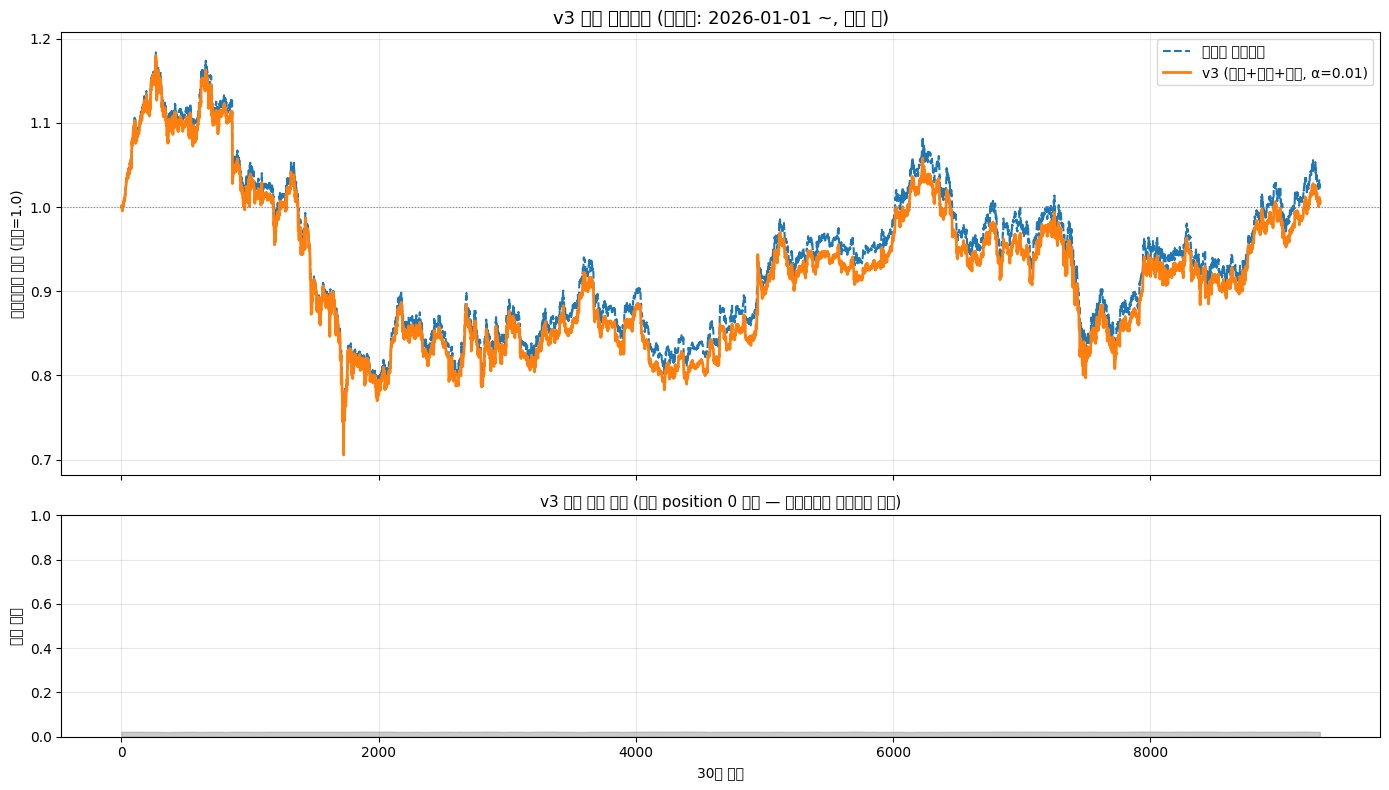

CPU times: user 42.5 s, sys: 52.1 ms, total: 42.5 s
Wall time: 44.2 s


In [ ]:
%%time
# §12-F — 실행 α를 valid에서 선택(테스트 누수 제거) 후, 2026 테스트는 최종 구성으로 단 1회 실행
def _perf_v3(net, gross, turnovers, steps_per_year=48 * 365):
    rets   = np.diff(net) / net[:-1]
    ann    = net[-1] ** (steps_per_year / len(rets)) - 1
    sharpe = rets.mean() / (rets.std() + 1e-8) * np.sqrt(steps_per_year)
    mdd    = ((net / np.maximum.accumulate(net)) - 1).min()
    t      = np.asarray(turnovers, dtype=np.float64)
    return {
        '총 수익률(비용 후)': f'{(net[-1]-1)*100:.2f}%',
        '총 수익률(비용 전)': f'{(gross[-1]-1)*100:.2f}%',
        '연환산':           f'{ann*100:.2f}%',
        'Sharpe':          f'{sharpe:.3f}',
        'MDD':             f'{mdd*100:.2f}%',
        '평균 턴오버/스텝':    f'{t.mean()*100:.2f}%',
    }


print('valid에서 실행 α 선택...')
alpha_valid = {}
for alpha in [0.05, 0.03, 0.02, 0.01]:
    vals, _, _, _, _ = run_router_v3(router_v3_best, v3_valid_buckets, alpha=alpha)
    alpha_valid[alpha] = vals[-1] - 1
    print(f'  α={alpha}: valid {(vals[-1]-1)*100:+.2f}%')
V3_FINAL_ALPHA = max(alpha_valid, key=alpha_valid.get)
print(f'▶ 최종 α = {V3_FINAL_ALPHA} (valid 기준 선택 — 테스트 데이터 미사용)\n')

print('=== 2026 테스트 최종 1회 실행 ===')
v3_net, v3_gross, v3_turns, v3_cash, v3_chosen = run_router_v3(
    router_v3_best, test_buckets, alpha=V3_FINAL_ALPHA)
_sel = pd.read_csv(CRYPTO_DIR / 'crypto_hrl_v3_pool_selection.csv')
_regimes = list(_sel.regime)
print('라우터 선택 분포:', {_regimes[k]: v for k, v in pd.Series(v3_chosen).value_counts().to_dict().items()})
print(f'평균 현금 비중: {np.mean(v3_cash)*100:.1f}% | 최대: {np.max(v3_cash)*100:.1f}%')

final_results, final_curves = {}, {}

_ew = CashPortfolioEnv(test_buckets, **env_kwargs)
_ew.reset()
_ewa = np.zeros(_ew.n_assets + 1, dtype=np.float32)
_ewa[:-1] = 1.0 / _ew.n_assets            # 등가중 44종목, 현금 0 — log-softmax 통과용
_ewg, _gg, d = [1.0], 1.0, False
_ew_logit = np.log(np.maximum(_ewa, 1e-12))
while not d:
    _, _, d, _, info = _ew.step(_ew_logit)
    _gg *= 1 + info['port_ret']
    _ewg.append(_gg)
final_results['등가중 벤치마크'] = _perf_v3(np.array(_ew.value_history), np.array(_ewg), _ew.turnover_history)
final_curves['등가중 벤치마크'] = np.array(_ew.value_history)

final_results[f'v3 (현금+선별+검증, α={V3_FINAL_ALPHA})'] = _perf_v3(v3_net, v3_gross, v3_turns)
final_curves[f'v3 (현금+선별+검증, α={V3_FINAL_ALPHA})'] = v3_net

final_df = pd.DataFrame(final_results).T
print()
print('참고(테스트 구간에서 α를 고른 §9 결과 — 직접 비교 시 주의): v1+스무딩 α=0.01 = +11.05% / Sharpe 0.638 / MDD -36.47%')
print(final_df.to_string())
final_df.to_csv(CRYPTO_DIR / 'crypto_hrl_v3_performance.csv', encoding='utf-8-sig')
print('\n저장 완료: crypto_hrl_v3_performance.csv')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax = axes[0]
for label, curve in final_curves.items():
    lw, ls = (1.5, '--') if '등가중' in label else (2.0, '-')
    ax.plot(curve, label=label, lw=lw, ls=ls)
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'v3 최종 백테스트 (테스트: {RL_TEST_START} ~, 비용 후)', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.fill_between(range(len(v3_cash)), v3_cash, 0, alpha=0.4, color='gray')
ax2.set_title('v3 현금 비중 추이 (논문 position 0 대응 — 하락장에서 올라가야 정상)', fontsize=11)
ax2.set_ylabel('현금 비중')
ax2.set_xlabel('30분 스텝')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_v3_backtest.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. v4 — FreQuant Top-K 희소선택 + DeepClair 리스크게이트 (저수준 액션만 교체)

**동기**: §12(v3) 진단 결과 — 44차원 연속 softmax 액션은 β 다양성 신호가 없으면 균등가중(1/45)으로 수렴한다.
DP 기반 Q-teacher를 포트폴리오(연속·다자산) 세팅에 이식하는 대신, 이번에는 **행동 공간 자체에 구조적
분리를 강제하는 장치**를 두 논문에서 가져온다.

- **FreQuant §4.2.2 (top-\|G\| 희소 선택)**: 전 종목에 대한 부드러운 softmax 대신, confidence score
  상위 K개만 골라 그 안에서만 정규화 배분한다(Eq. 13–14). 44개를 섞을 자유를 없애 "어떤 종목을 고를지"
  자체를 강제 결정하게 만든다.
- **DeepClair §4.2.3 (Market Scoring Module의 ρ)**: 종목 선택과 별개로 "총 익스포저를 얼마나 가져갈지"를
  전용 스칼라 출력(게이트)으로 분리한다. v3에서 현금 비중이 44개 종목 로짓 사이에 묻혀 아예 학습되지
  않았던 문제(전 구간 2.2% 고정)를 직접 겨냥한 설계.

EarnHFT의 Stage A(레짐 분할)·Stage B(β 다양성 풀)·Stage C(라우터) 골격과 추론 시 관성 스무딩(§9, 검증됨)은
그대로 재사용하고, **저수준 환경(`CryptoPortfolioEnv` → `SparseGatedCryptoPortfolioEnv`)만 교체**한다.
Stage A 청크(`seg.chunks`)·`chunk_sampling_priority`(§4)는 이미 계산된 것을 그대로 쓴다.

**간소화 지점(보고서 명시용)**: top-K(=10)는 스윕 없이 고정(44종목 대비 경험적 선택). 시간이 되면
`TOP_K ∈ {5, 10, 15, 20}` 스윕 권장. PPO의 기본 가우시안 탐색 노이즈를 그대로 사용하며, DeepClair
원문의 명시적 `N(μ,σ)` 샘플링·보조 리워드(r2)는 이식하지 않았다(스코프 최소화).

**판정 기준**: §13-H 진단에서 ρ와 top-K 종목 구성이 시간에 따라 실제로 변하는지(1차, v3 재발 여부)를
먼저 확인하고, 그 다음 §13-F/G 성능표에서 등가중·v1(+스무딩)을 넘는지(2차)를 본다.

### 13-A. SparseGatedCryptoPortfolioEnv 정의

In [11]:
TOP_K = 10   # 종목 유니버스(44) 중 매 스텝 보유 가능한 최대 종목 수 (FreQuant top-|G| 이식)

class SparseGatedCryptoPortfolioEnv(CryptoPortfolioEnv):
    """
    FreQuant(top-K 희소 선택) + DeepClair(전용 리스크게이트 ρ) 결합 저수준 환경.

    Action: (N+1,)-dim — 앞 N개는 종목별 confidence logit(FreQuant Eq.13-14의 h_i 역할),
            마지막 1개는 리스크자산 총 노출 게이트 로짓(DeepClair의 ρ_t 역할).
    변환:   top-K confidence logit만 골라 그 안에서 softmax(FreQuant Eq.14) →
            sigmoid(게이트)를 곱해 최종 종목별 비중. 나머지는 암묵적 현금(수익률 0).
    관측·NAV 회계는 CryptoPortfolioEnv와 동일. step_with_weights()는 목표 비중을 직접
    받아 NAV를 갱신하는 보조 메서드 — §13-G 관성 스무딩에서 (top-K 변환을 다시 태우지 않고)
    이미 블렌딩된 비중을 그대로 반영하기 위해 필요하다.
    """

    def __init__(self, *args, top_k=TOP_K, **kwargs):
        self.top_k = top_k
        super().__init__(*args, **kwargs)
        self.action_space = spaces.Box(-3.0, 3.0, shape=(self.n_assets + 1,), dtype=np.float32)

    def action_to_weights(self, action):
        action = np.asarray(action, dtype=np.float64)
        asset_logits, gate_logit = action[:-1], action[-1]
        k = min(self.top_k, self.n_assets)
        top_idx = np.argpartition(asset_logits, -k)[-k:]
        sel = asset_logits[top_idx]
        sel = np.exp(sel - sel.max())
        sel = sel / sel.sum()
        risky_w = np.zeros(self.n_assets, dtype=np.float32)
        risky_w[top_idx] = sel
        rho = float(1.0 / (1.0 + np.exp(-gate_logit)))
        return (rho * risky_w).astype(np.float32), rho, top_idx

    def reset(self, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        self.rho_history = []
        self.selection_history = []
        return obs, info

    def step_with_weights(self, target_w, extra_info=None):
        turnover = float(np.abs(target_w - self.weights).sum())
        tc_cost  = self.tc * turnover
        b          = self.buckets[self.t]
        asset_rets = self._asset_ret(b)
        port_ret   = float((target_w * asset_rets).sum())

        self.portfolio_value *= (1 + port_ret - tc_cost)
        self.weights           = target_w.copy()
        self.value_history.append(self.portfolio_value)
        self.turnover_history.append(turnover)
        self.t                += 1

        done = (self.t >= len(self.buckets) - 1)
        reward = float(port_ret - tc_cost)
        info = {'portfolio_value': self.portfolio_value, 'port_ret': port_ret,
                'turnover': turnover, 'tc_cost': tc_cost}
        if extra_info:
            info.update(extra_info)
            if 'rho' in extra_info:
                self.rho_history.append(extra_info['rho'])
            if 'selected' in extra_info:
                self.selection_history.append(extra_info['selected'])
        return self._get_obs(), reward, done, False, info

    def step(self, action):
        target_w, rho, top_idx = self.action_to_weights(action)
        return self.step_with_weights(target_w, extra_info={'rho': rho, 'selected': top_idx.tolist()})


# 스모크 테스트
_sg_env = SparseGatedCryptoPortfolioEnv(test_buckets[:200], top_k=TOP_K, **env_kwargs)
check_env(_sg_env, warn=True)
obs, _ = _sg_env.reset()
a = np.random.randn(_sg_env.n_assets + 1).astype(np.float32)
obs, r, done, _, info = _sg_env.step(a)
print(f"action space: {_sg_env.action_space.shape} | 선택된 종목 수: {len(info['selected'])} | "
      f"rho: {info['rho']:.3f} | reward: {r:.5f}")

action space: (45,) | 선택된 종목 수: 10 | rho: 0.186 | reward: -0.00087


### 13-B. Stage B용 청크 샘플링 환경 (§5의 β 우선순위 로직 재사용)

In [ ]:
class ChunkedSparseGatedEnv(SparseGatedCryptoPortfolioEnv):
    """§5의 ChunkedCryptoPortfolioEnv와 동일한 β-우선순위 청크 샘플링, 저수준 환경만 v4로 교체."""

    def __init__(self, all_buckets, chunks, beta, risk_threshold=0.2, rng=None, top_k=TOP_K, **env_kwargs):
        self.all_buckets = all_buckets
        self.chunks      = chunks.reset_index(drop=True)
        self.beta        = beta
        self.priority    = chunk_sampling_priority(self.chunks, beta, risk_threshold)
        self.rng         = rng or np.random.default_rng()
        super().__init__(buckets=all_buckets[:2], top_k=top_k, **env_kwargs)  # reset()에서 실제 구간으로 교체됨

    def reset(self, seed=None, options=None):
        idx = self.rng.choice(len(self.chunks), p=self.priority)
        row = self.chunks.iloc[idx]
        self.buckets = self.all_buckets[int(row['start_idx']):int(row['end_idx']) + 1]
        return super().reset(seed=seed, options=options)


# 스모크 테스트
_test_env_v4 = ChunkedSparseGatedEnv(
    all_buckets=train_buckets, chunks=seg.chunks, beta=90, rng=np.random.default_rng(0), **env_kwargs
)
for _ in range(3):
    _test_env_v4.reset()
    print(f"β=90 샘플 구간: {len(_test_env_v4.buckets)}버킷 "
          f"({bucket_to_date(_test_env_v4.buckets[0])} ~ {bucket_to_date(_test_env_v4.buckets[-1])})")

β=90 샘플 구간: 89버킷 (2025-08-12 ~ 2025-08-13)
β=90 샘플 구간: 59버킷 (2025-03-03 ~ 2025-03-04)
β=90 샘플 구간: 59버킷 (2025-01-13 ~ 2025-01-14)


### 13-C. Stage B — v4 저수준 환경으로 풀 재학습 (§5와 동일 예산: 4β × 100k 스텝)

In [ ]:
%%time
POOL_DIR_V4 = MODEL_DIR / 'crypto_hrl_pool_v4'
POOL_DIR_V4.mkdir(parents=True, exist_ok=True)
pool_models_v4 = {}

for pool_i, beta in enumerate(POOL_BETAS):
    print(f'\n=== [v4] β={beta} 에이전트 학습 ({POOL_TIMESTEPS_EACH:,} 스텝) ===')
    rng = np.random.default_rng(2000 + pool_i)
    chunk_env = Monitor(ChunkedSparseGatedEnv(
        all_buckets=train_buckets, chunks=seg.chunks, beta=beta,
        risk_threshold=RISK_THRESHOLD, rng=rng, top_k=TOP_K, **env_kwargs,
    ))
    model = PPO(
        'MlpPolicy', chunk_env,
        learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
        max_grad_norm=0.5, policy_kwargs=dict(net_arch=[512, 256]),
        verbose=0, device='cpu', seed=42,
    )
    model.learn(total_timesteps=POOL_TIMESTEPS_EACH, progress_bar=True)

    save_path = POOL_DIR_V4 / f'agent_beta_{beta}.zip'
    model.save(str(save_path))
    pool_models_v4[beta] = model
    print(f'저장: {save_path.name}')

print(f'\n[v4] 풀 학습 완료: {len(pool_models_v4)}개 에이전트')


=== [v4] β=-90 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_-90.zip

=== [v4] β=-30 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_-30.zip

=== [v4] β=30 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_30.zip

=== [v4] β=90 에이전트 학습 (100,000 스텝) ===


Output()

저장: agent_beta_90.zip

[v4] 풀 학습 완료: 4개 에이전트
CPU times: user 1h 8min 51s, sys: 22.2 s, total: 1h 9min 13s
Wall time: 1h 11min 1s


### 13-D. Stage C — v4 라우터 (§6과 동일 구조·예산, 저수준 환경만 교체)

In [12]:
class MacroRouterEnvV4(gym.Env):
    """§6 MacroRouterEnv와 동일 로직, 저수준 환경만 SparseGatedCryptoPortfolioEnv로 교체."""
    metadata = {'render_modes': []}

    def __init__(self, buckets, pool_models, route_buckets=48, macro_window=96, top_k=TOP_K, **env_kwargs):
        super().__init__()
        self.pool_models    = list(pool_models)
        self.route_buckets  = route_buckets
        self.macro_window   = macro_window
        self.inner           = SparseGatedCryptoPortfolioEnv(buckets=buckets, top_k=top_k, **env_kwargs)
        self.action_space      = spaces.Discrete(len(self.pool_models))
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(macro_window + 4,), dtype=np.float32)
        self._nav_history = []

    def _macro_obs(self):
        hist = self._nav_history[-self.macro_window:]
        if len(hist) < self.macro_window:
            hist = [1.0] * (self.macro_window - len(hist)) + hist
        recent = np.array(hist, dtype=np.float32)
        ret = np.diff(recent) if len(recent) > 1 else np.zeros(1, dtype=np.float32)
        stats = np.array([
            recent[-1] - recent[0],
            float(ret.std()),
            float(ret.mean()),
            self.inner.t / max(len(self.inner.buckets) - 1, 1),
        ], dtype=np.float32)
        return np.concatenate([recent, stats]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.inner.reset(seed=seed)
        self._nav_history = []
        return self._macro_obs(), {}

    def step(self, action):
        model = self.pool_models[int(action)]
        block_reward = 0.0
        done_inner = False
        for _ in range(self.route_buckets):
            obs = self.inner._get_obs()
            a, _ = model.predict(obs, deterministic=True)
            _, r, done_inner, _, info = self.inner.step(a)
            block_reward += r
            self._nav_history.append(info['portfolio_value'])
            if done_inner:
                break
        done = done_inner or self.inner.t >= len(self.inner.buckets) - 1
        info = {'portfolio_value': self.inner.portfolio_value}
        return self._macro_obs(), block_reward, done, False, info


# 스모크 테스트 — pool_models_v4가 아직 없는 세션(§13-C를 건너뛰고 §13-로더만 나중에 실행하는
# 복구 경로)에서도 이 셀이 클래스 정의만은 항상 성공하도록 방어.
if 'pool_models_v4' in globals() and pool_models_v4:
    _router_probe_v4 = MacroRouterEnvV4(
        buckets=train_buckets[:500], pool_models=list(pool_models_v4.values()),
        route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, top_k=TOP_K, **env_kwargs,
    )
    obs, _ = _router_probe_v4.reset()
    print('[v4] router obs shape:', obs.shape)
    obs, r, done, _, info = _router_probe_v4.step(0)
    print('[v4] 1스텝 후 reward:', r, 'portfolio_value:', info['portfolio_value'])
else:
    print('MacroRouterEnvV4 클래스 정의 완료 (pool_models_v4 없음 — 스모크 테스트 생략, §13-로더 실행 후 계속 진행)')

MacroRouterEnvV4 클래스 정의 완료 (pool_models_v4 없음 — 스모크 테스트 생략, §13-로더 실행 후 계속 진행)


In [ ]:
%%time
router_env_v4 = Monitor(MacroRouterEnvV4(
    buckets=train_buckets, pool_models=[pool_models_v4[b] for b in POOL_BETAS],
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, top_k=TOP_K, **env_kwargs,
))

router_v4 = DQN(
    'MlpPolicy', router_env_v4,
    learning_rate=1e-3, buffer_size=20_000, learning_starts=500,
    batch_size=64, gamma=0.95, train_freq=1, target_update_interval=200,
    exploration_fraction=0.3, exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[128, 64]),
    verbose=1, device='cpu', seed=42,
)
router_v4.learn(total_timesteps=ROUTER_TOTAL_TIMESTEPS, progress_bar=True)

router_v4_path = MODEL_DIR / 'crypto_hrl_router_v4.zip'
router_v4.save(str(router_v4_path))
print(f'[v4] 라우터 저장: {router_v4_path.name}')

Output()

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 365      |
|    ep_rew_mean      | -0.661   |
|    exploration_rate | 0.769    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 11       |
|    time_elapsed     | 122      |
|    total_timesteps  | 1460     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 4.75e-05 |
|    n_updates        | 959      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 365      |
|    ep_rew_mean      | -0.664   |
|    exploration_rate | 0.538    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 12       |
|    time_elapsed     | 236      |
|    total_timesteps  | 2920     |
| train/              |          |
|    learning_rate    | 0.001    |
|  

[v4] 라우터 저장: crypto_hrl_router_v4.zip
CPU times: user 25min 23s, sys: 8.79 s, total: 25min 32s
Wall time: 26min 21s


In [13]:
# [v4] 진단 재실행용 로더 — 세션이 끊겨도 저장된 모델만 불러와 이어서 백테스트 가능
# (§13-C 학습 셀을 건너뛴 경로에서는 POOL_DIR_V4가 아직 없으므로 여기서 재정의 — 경로만 가리킬 뿐 idempotent)
POOL_DIR_V4 = MODEL_DIR / 'crypto_hrl_pool_v4'
if 'pool_models_v4' not in globals() or not pool_models_v4:
    pool_models_v4 = {b: PPO.load(str(POOL_DIR_V4 / f'agent_beta_{b}.zip')) for b in POOL_BETAS}
    print('[v4] 풀 에이전트 로드 완료:', list(pool_models_v4.keys()))
if 'router_v4' not in globals():
    router_v4 = DQN.load(str(MODEL_DIR / 'crypto_hrl_router_v4.zip'))
    print('[v4] 라우터 로드 완료')

[v4] 풀 에이전트 로드 완료: [-90, -30, 30, 90]
[v4] 라우터 로드 완료


### 13-E. 최종 백테스트 — v4 vs v1(+스무딩) vs 등가중

In [14]:
# 방어적 재계산 — §7/§9를 건너뛰고 로더 셀만 실행한 세션 대비
if 'ew_values' not in globals():
    ew_values, ew_turnovers = equal_weight_backtest(CryptoPortfolioEnv(test_buckets, **env_kwargs))
if 'hrl_values' not in globals():
    _v1_test_env = MacroRouterEnv(
        buckets=test_buckets, pool_models=[pool_models[b] for b in POOL_BETAS],
        route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, **env_kwargs,
    )
    _obs, _ = _v1_test_env.reset()
    _done = False
    while not _done:
        _a, _ = router.predict(_obs, deterministic=True)
        _obs, _, _done, _, _ = _v1_test_env.step(_a)
    hrl_values    = np.array(_v1_test_env.inner.value_history)
    hrl_turnovers = list(_v1_test_env.inner.turnover_history)

print('[v4] 테스트 구간에서 라우터+풀 시스템 실행 중...')
router_test_env_v4 = MacroRouterEnvV4(
    buckets=test_buckets, pool_models=[pool_models_v4[b] for b in POOL_BETAS],
    route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, top_k=TOP_K, **env_kwargs,
)
obs, _ = router_test_env_v4.reset()
done, chosen_v4 = False, []
while not done:
    action, _ = router_v4.predict(obs, deterministic=True)
    chosen_v4.append(int(action))
    obs, _, done, _, info = router_test_env_v4.step(action)

v4_values    = np.array(router_test_env_v4.inner.value_history)
v4_turnovers = list(router_test_env_v4.inner.turnover_history)
print('[v4] 라우터 선택 분포(β):', {POOL_BETAS[k]: v for k, v in pd.Series(chosen_v4).value_counts().to_dict().items()})

print(f'[v1 참조] 관성 스무딩 α={BEST_ALPHA} 재실행 중...')
v1_smoothed_net, _, v1_smoothed_turnovers = run_hrl_smoothed(BEST_ALPHA)

v4_comparison = {
    '등가중 벤치마크':                     compute_perf(ew_values),
    'v1 라우터+풀 (스무딩 없음)':            compute_perf(hrl_values),
    f'v1 + 스무딩 α={BEST_ALPHA}':          compute_perf(v1_smoothed_net),
    'v4 라우터+풀 (스무딩 없음)':            compute_perf(v4_values),
}
v4_turnover_comparison = {
    '등가중 벤치마크':                     turnover_stats(ew_turnovers),
    'v1 라우터+풀 (스무딩 없음)':            turnover_stats(hrl_turnovers),
    f'v1 + 스무딩 α={BEST_ALPHA}':          turnover_stats(v1_smoothed_turnovers),
    'v4 라우터+풀 (스무딩 없음)':            turnover_stats(v4_turnovers),
}

v4_perf_df = pd.DataFrame(v4_comparison).T
print()
print(v4_perf_df.to_string())
v4_perf_df.to_csv(CRYPTO_DIR / 'crypto_hrl_v4_performance.csv', encoding='utf-8-sig')

v4_turnover_df = pd.DataFrame(v4_turnover_comparison).T
print()
print('--- [v4] 턴오버/거래비용 진단 ---')
print(v4_turnover_df.to_string())
v4_turnover_df.to_csv(CRYPTO_DIR / 'crypto_hrl_v4_turnover_diag.csv', encoding='utf-8-sig')
print('\n저장 완료: crypto_hrl_v4_performance.csv, crypto_hrl_v4_turnover_diag.csv')

[v4] 테스트 구간에서 라우터+풀 시스템 실행 중...
[v4] 라우터 선택 분포(β): {-30: 99, 30: 96}
[v1 참조] 관성 스무딩 α=0.01 재실행 중...

                     총 수익률  연환산 수익률  Sharpe      MDD
등가중 벤치마크             2.66%    5.05%   0.367  -40.09%
v1 라우터+풀 (스무딩 없음)  -32.24%  -51.90%  -1.107  -50.04%
v1 + 스무딩 α=0.01     11.05%   21.79%   0.638  -36.47%
v4 라우터+풀 (스무딩 없음)  -22.96%  -38.76%  -7.107  -23.61%

--- [v4] 턴오버/거래비용 진단 ---
                  평균 턴오버/스텝 중앙값 턴오버/스텝 스텝당 평균 거래비용 누적 거래비용 드래그(총자산 대비)
등가중 벤치마크               0.0%       0.0%     0.0000%               0.00%
v1 라우터+풀 (스무딩 없음)      5.4%       4.0%     0.0054%              39.81%
v1 + 스무딩 α=0.01        0.1%       0.1%     0.0001%               1.32%
v4 라우터+풀 (스무딩 없음)      2.7%       1.1%     0.0027%              22.50%

저장 완료: crypto_hrl_v4_performance.csv, crypto_hrl_v4_turnover_diag.csv


### 13-F. v4에 관성 스무딩 적용 (§9와 동일 α 스윕, step_with_weights로 top-K 재변환 없이 블렌딩)

v4 α=1.0 (스무딩 없음) 실행 중...
v4 α=0.3 실행 중...
v4 α=0.15 실행 중...
v4 α=0.05 실행 중...
v4 α=0.03 실행 중...
v4 α=0.02 실행 중...
v4 α=0.01 실행 중...

                  총 수익률(비용 후) 총 수익률(비용 전)      연환산  Sharpe      MDD 평균 턴오버/스텝 누적 비용 드래그
v4 α=1.0 (스무딩 없음)     -22.96%      -0.60%  -38.76%  -7.107  -23.61%     2.73%    22.50%
v4 α=0.3               -9.12%       5.02%  -16.45%  -2.567  -12.21%     1.55%    13.46%
v4 α=0.15              -2.77%       5.40%   -5.14%  -0.747   -7.00%     0.87%     7.75%
v4 α=0.05               3.10%       6.10%    5.90%   0.892   -5.59%     0.31%     2.83%
v4 α=0.03               4.93%       6.78%    9.46%   1.387   -5.37%     0.19%     1.74%
v4 α=0.02               6.37%       7.62%   12.30%   1.762   -5.27%     0.13%     1.16%
v4 α=0.01               8.26%       8.91%   16.09%   2.168   -5.22%     0.06%     0.60%

[v4] 비용 후 최고 α = 0.01 (총 수익률 8.26%)
저장 완료: crypto_hrl_v4_smoothing_sweep.csv


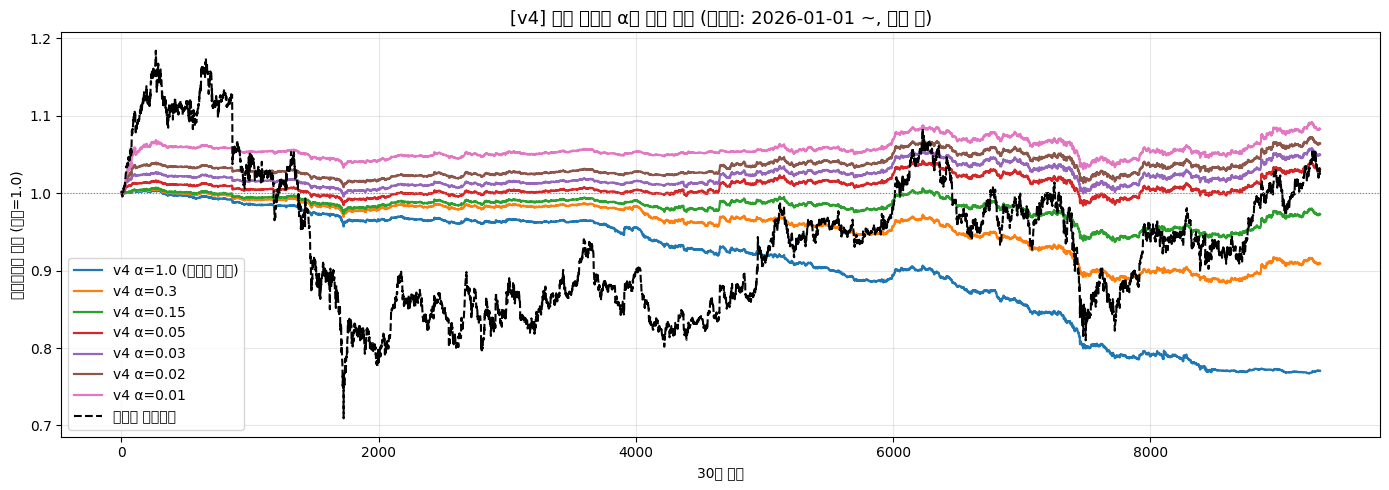

CPU times: user 1min 24s, sys: 242 ms, total: 1min 24s
Wall time: 1min 27s


In [15]:
%%time
def run_v4_smoothed(alpha):
    """v4 라우터+풀을 테스트 구간에서 실행하되 최종 비중에 관성 스무딩 적용.
    top-K 변환은 비가역적(0이 된 종목의 log를 취할 수 없음)이라 §9의 log-트릭 대신
    action_to_weights()로 얻은 목표 비중을 직접 블렌딩해 step_with_weights()로 반영한다."""
    env = MacroRouterEnvV4(
        buckets=test_buckets, pool_models=[pool_models_v4[b] for b in POOL_BETAS],
        route_buckets=ROUTE_BUCKETS, macro_window=MACRO_WINDOW, top_k=TOP_K, **env_kwargs,
    )
    obs, _ = env.reset()
    inner = env.inner
    gross, g = [1.0], 1.0
    done = False
    while not done:
        r_action, _ = router_v4.predict(obs, deterministic=True)
        model = env.pool_models[int(r_action)]
        done_inner = False
        for _ in range(env.route_buckets):
            a, _ = model.predict(inner._get_obs(), deterministic=True)
            target_w, rho, top_idx = inner.action_to_weights(a)
            w = (1 - alpha) * inner.weights + alpha * target_w
            _, _, done_inner, _, info = inner.step_with_weights(w, extra_info={'rho': rho, 'selected': top_idx.tolist()})
            env._nav_history.append(info['portfolio_value'])
            g *= 1 + info['port_ret']
            gross.append(g)
            if done_inner:
                break
        obs = env._macro_obs()
        done = done_inner or inner.t >= len(inner.buckets) - 1
    return np.array(inner.value_history), np.array(gross), list(inner.turnover_history), inner


v4_smooth_results, v4_smooth_curves = {}, {}
_v4_net_by_alpha, _v4_env_by_alpha = {}, {}
for alpha in SMOOTH_ALPHAS:
    label = 'v4 α=1.0 (스무딩 없음)' if alpha == 1.0 else f'v4 α={alpha}'
    print(f'{label} 실행 중...')
    net, gross, turns, inner_env = run_v4_smoothed(alpha)
    v4_smooth_results[label] = smooth_perf_row(net, gross, turns)
    v4_smooth_curves[label]  = net
    _v4_net_by_alpha[alpha]  = net[-1]
    _v4_env_by_alpha[alpha]  = inner_env

BEST_ALPHA_V4 = max((a for a in _v4_net_by_alpha if a < 1.0), key=lambda a: _v4_net_by_alpha[a])

v4_smooth_df = pd.DataFrame(v4_smooth_results).T
print()
print(v4_smooth_df.to_string())
print(f"\n[v4] 비용 후 최고 α = {BEST_ALPHA_V4} (총 수익률 {(_v4_net_by_alpha[BEST_ALPHA_V4]-1)*100:.2f}%)")
v4_smooth_df.to_csv(CRYPTO_DIR / 'crypto_hrl_v4_smoothing_sweep.csv', encoding='utf-8-sig')
print('저장 완료: crypto_hrl_v4_smoothing_sweep.csv')

fig, ax = plt.subplots(figsize=(14, 5))
for label, curve in v4_smooth_curves.items():
    ax.plot(curve, label=label, lw=1.6)
ax.plot(ew_values, label='등가중 벤치마크', lw=1.5, ls='--', color='black')
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'[v4] 관성 스무딩 α별 누적 가치 (테스트: {RL_TEST_START} ~, 비용 후)', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.set_xlabel('30분 스텝')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_v4_smoothing_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

### 13-F-보조. 저턴오버 아티팩트 진단 — α=BEST_ALPHA_V4가 정적 포지션인지 확인

=== [v4] α=0.01 정적 포지션 아티팩트 진단 (n=9319 스텝) ===

턴오버 — 전체 평균 0.0649% | 앞 10% 평균 0.1140% | 뒤 10% 평균 0.0881% | 뒤 10% 구간 중 턴오버=0인 스텝 비율 0.0%

전반부 수익률: 5.47% | 후반부 수익률: 2.64%
(후반부가 0%에 가깝거나 음수인데 전반부만 크게 플러스면, 초반에 잡은 포지션이 그대로 버틴 정적 결과라는 뜻)

앞 1/4 구간 선택 종목 집합: 20개 | 뒤 1/4 구간: 23개 | 자카드 유사도: 0.26 (1.0=완전 동일 종목만 계속 선택, 낮을수록 실제로 회전)


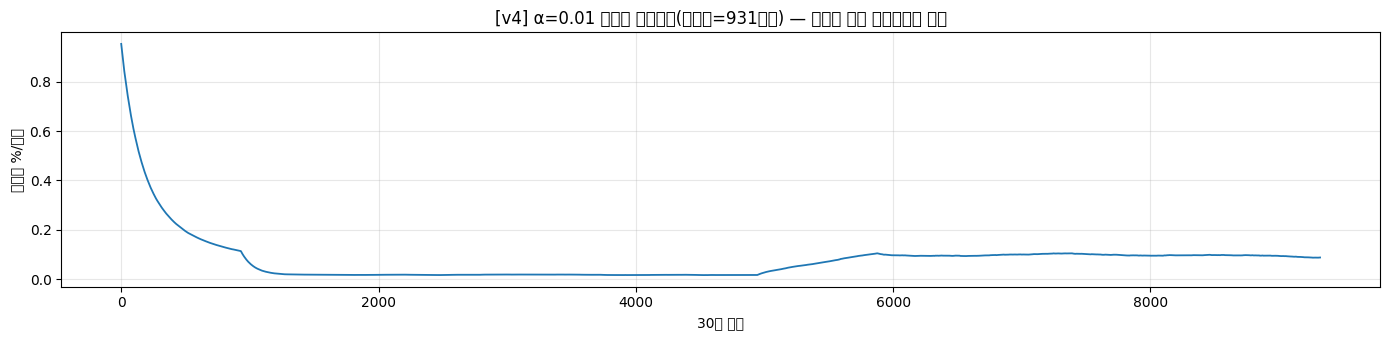

In [16]:
# 13-F 보조 진단 — v4 α=BEST_ALPHA_V4 결과(비용 후 8.26%)가 "초반에 우연히 잡은 포지션이
# 그대로 버틴" 정적 아티팩트인지, 아니면 꾸준한 리밸런싱으로 만들어진 성과인지 확인한다.
# (v3 §12에서 "pullback 단독 +8.05%"가 회전 거의 없는 관측치라 전략으로 인용 금지했던 것과
# 같은 함정이 v4 α=0.01(턴오버 0.06%/스텝)에도 있는지 점검.)

if '_v4_env_by_alpha' in globals() and BEST_ALPHA_V4 in _v4_env_by_alpha:
    diag_env = _v4_env_by_alpha[BEST_ALPHA_V4]
else:
    print(f'캐시된 env 없음 — α={BEST_ALPHA_V4} 재실행...')
    _, _, _, diag_env = run_v4_smoothed(BEST_ALPHA_V4)

turns  = np.array(diag_env.turnover_history)
values = np.array(diag_env.value_history)
n = len(turns)
decile = max(n // 10, 1)

print(f'=== [v4] α={BEST_ALPHA_V4} 정적 포지션 아티팩트 진단 (n={n} 스텝) ===\n')
print(f'턴오버 — 전체 평균 {turns.mean()*100:.4f}% | 앞 10% 평균 {turns[:decile].mean()*100:.4f}% | '
      f'뒤 10% 평균 {turns[-decile:].mean()*100:.4f}% | 뒤 10% 구간 중 턴오버=0인 스텝 비율 '
      f'{(turns[-decile:] == 0).mean()*100:.1f}%')

half = n // 2
first_half_ret  = values[half] / values[0] - 1
second_half_ret = values[-1]  / values[half] - 1
print(f'\n전반부 수익률: {first_half_ret*100:.2f}% | 후반부 수익률: {second_half_ret*100:.2f}%')
print('(후반부가 0%에 가깝거나 음수인데 전반부만 크게 플러스면, 초반에 잡은 포지션이 그대로 버틴 정적 결과라는 뜻)')

# 목표 선택(top-K)이 시간에 따라 실제로 회전하는지 — 앞/뒤 1/4 구간 자산 겹침(자카드 유사도)
sel = diag_env.selection_history
q = max(n // 4, 1)
first_q_assets = set(a for s in sel[:q] for a in s)
last_q_assets  = set(a for s in sel[-q:] for a in s)
jaccard = len(first_q_assets & last_q_assets) / len(first_q_assets | last_q_assets)
print(f'\n앞 1/4 구간 선택 종목 집합: {len(first_q_assets)}개 | 뒤 1/4 구간: {len(last_q_assets)}개 | '
      f'자카드 유사도: {jaccard:.2f} (1.0=완전 동일 종목만 계속 선택, 낮을수록 실제로 회전)')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(pd.Series(turns).rolling(decile, min_periods=1).mean() * 100, lw=1.3)
ax.set_title(f'[v4] α={BEST_ALPHA_V4} 턴오버 롤링평균(윈도우={decile}스텝) — 시간에 따라 죽어가는지 확인', fontsize=12)
ax.set_ylabel('턴오버 %/스텝')
ax.set_xlabel('30분 스텝')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CRYPTO_DIR / 'crypto_hrl_v4_turnover_rolling.png', dpi=150, bbox_inches='tight')
plt.show()


### 13-G. 다양성 진단 — v3(균등가중 수렴)가 재발했는지 확인

In [17]:
print('=== [v4] 진단: 다양성이 실제로 생겼는가? ===\n')

# 1. 라우터+풀 실행(스무딩 없음) 중 리스크게이트(ρ) 분포
rho_arr = np.array(router_test_env_v4.inner.rho_history)
print(f'ρ(리스크 익스포저) — 평균 {rho_arr.mean():.3f} | 표준편차 {rho_arr.std():.3f} | '
      f'최소 {rho_arr.min():.3f} | 최대 {rho_arr.max():.3f}')
print('(v3에서는 현금 비중이 전 구간 2.2%로 고정 — ρ가 시간에 따라 변한다면 게이트가 실제로 학습된 것)\n')

# 2. β별 풀 에이전트 단독 평균 ρ — 레짐 다양성 진단 (v1 §7 '평균 포지션 β별' 대응)
print('--- β별 풀 에이전트 단독 평균 ρ (각자 자기 선호 레짐 청크에서, train 구간) ---')
for beta in POOL_BETAS:
    probe = ChunkedSparseGatedEnv(
        all_buckets=train_buckets, chunks=seg.chunks, beta=beta,
        risk_threshold=RISK_THRESHOLD, rng=np.random.default_rng(999), top_k=TOP_K, **env_kwargs,
    )
    obs, _ = probe.reset()
    done = False
    while not done:
        a, _ = pool_models_v4[beta].predict(obs, deterministic=True)
        obs, _, done, _, _ = probe.step(a)
    print(f'  β={beta:>4d}: 평균 ρ={np.mean(probe.rho_history):.3f}')

# 3. 종목 선택 다양성 — top-K 안에 실제로 몇 개 종목이 돌아가며 뽑혔는가 (테스트 구간, 스무딩 없음)
from collections import Counter
sel_counter = Counter()
for sel in router_test_env_v4.inner.selection_history:
    sel_counter.update(sel)
n_unique = len(sel_counter)
top10 = sel_counter.most_common(10)
print(f"\n테스트 기간 중 top-{TOP_K} 안에 한 번이라도 뽑힌 종목 수: {n_unique} / {N_ASSETS}")
print('가장 자주 뽑힌 종목(횟수):', [(symbols[i], c) for i, c in top10])

=== [v4] 진단: 다양성이 실제로 생겼는가? ===

ρ(리스크 익스포저) — 평균 0.117 | 표준편차 0.068 | 최소 0.047 | 최대 0.327
(v3에서는 현금 비중이 전 구간 2.2%로 고정 — ρ가 시간에 따라 변한다면 게이트가 실제로 학습된 것)

--- β별 풀 에이전트 단독 평균 ρ (각자 자기 선호 레짐 청크에서, train 구간) ---


NameError: name 'ChunkedSparseGatedEnv' is not defined

### 13-H. 판정 기준 (실행 후 이 셀 기준으로 §13 결과 해석)

1. **1차 (필수, §13-G)**: ρ가 시간에 따라 유의미하게 변하고(예: 표준편차 > 0.05), β별 평균 ρ에 순서가
   생기며, top-K 종목 구성이 테스트 기간 동안 상당수 종목(예: 44개 중 15개 이상)에 걸쳐 회전하는가 —
   v3의 "균등가중 수렴" 재발 여부 확인. 여기서 실패하면(ρ 거의 고정, 항상 같은 K종목) top-K+게이트
   구조도 다양성을 만들지 못했다는 뜻이며, Stage B/C 재설계보다 더 근본적인 재검토(예: 보상에 명시적
   다양성 페널티 추가, top-K 대신 하드 제약이 아닌 소프트 sparsity 정규화)가 필요하다.
2. **2차 (성능, §13-E/F)**: `v4 + 스무딩(α=BEST_ALPHA_V4)`이 `등가중 벤치마크`·`v1 + 스무딩`을 비용 후
   총수익률·Sharpe 기준으로 넘는가.
3. 1차는 통과했지만 2차에서 지면: "구조적 분리는 됐으나 예측 신호 자체가 약하다"는 v3와는 다른 실패
   모드로 기록할 가치가 있다(v3는 애초에 다양성 자체가 발생하지 않았음). 이 경우 다음 후보는 top-K를
   줄여(예: 5) 회전을 더 억제하거나, BTC 단일자산 트랙(§7 PROGRESS.md)의 κ 히스테리시스를 이식하는 것.